In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#part1
import os
import sys
import gc
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import torch

main_folder = "../.."
sys.path.insert(0, os.path.join(main_folder))

from src.config import EXP_CONFIGS
from src.inference_feedback import (
    extract_aux_oof_to_csv,
    sweep_thresholds, uncertainty_band, assign_reliability,
    load_model,
    run_batch,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TARGET     = "Pawpularity"
IMG_FOLDER = os.path.join(main_folder, "data", "train")
CSV_PATH   = os.path.join(main_folder, "data", "train.csv")
df         = pd.read_csv(CSV_PATH)
AUX_TASKS  = ["Eyes","Face","Occlusion", "Blur",
                             "Subject Focus","Action","Accessory",
                             "Near", "Group","Collage","Human", "Info"]
SWIN_GRID  = (12, 12)

# exp19: standard BCE aux heads
out_dir_exp19 = os.path.join(main_folder, "outputs", "extra",
                             "exp19_swin_384_strong_MSELoss_All12_Aux_StrongHead_fixDupOcclusion")

cfg_exp19 = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg_exp19["img_size"] = 384
cfg_exp19["name"] = "exp19_swin_384_strong_MSELoss_All12_Aux_StrongHead_fixDupOcclusion"
cfg_exp19["loss"] = "mse"
cfg_exp19["head_type"] = "mlp"
cfg_exp19["aux_tasks"] = []
cfg_exp19["binary_aux_tasks"]   = ["Eyes","Face","Occlusion", "Blur",
                             "Subject Focus","Action","Accessory",
                             "Near", "Group","Collage","Human", "Info"]  # all 12 binary aux tasks
cfg_exp19["aux_loss_weights"]   = {
    "Face":      0.1,
    "Eyes":      0.1,
    "Occlusion": 0.1,
    "Blur":      0.1,
    "Subject Focus": 0.1,
    "Action": 0.1,
    "Accessory": 0.1,
    "Group": 0.1,
    "Collage": 0.1,
    "Human": 0.1,
    "Info": 0.1,
    "Near": 0.1
}
cfg_exp19["use_saliency"] = False

ACTIVE_CFG = cfg_exp19
ACTIVE_DIR = out_dir_exp19


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [4]:
#part2
# To create the aux head with the probabilities for each record and each aux head and save it to a CSV file
aux_df = extract_aux_oof_to_csv(
    out_dir=ACTIVE_DIR,
    df=df,
    img_folder=IMG_FOLDER,
    cfg=ACTIVE_CFG,
    device=device,
)

Loading existing: ../../outputs/extra/exp19_swin_384_strong_MSELoss_All12_Aux_StrongHead_fixDupOcclusion/oof_detail_aux.csv


In [5]:
#part3
aux_df.head()

,Id,fold,ytrue,Eyes_true,Eyes_prob,Eyes_pred_05,Face_true,Face_prob,Face_pred_05,Occlusion_true,...,Group_pred_05,Collage_true,Collage_prob,Collage_pred_05,Human_true,Human_prob,Human_pred_05,Info_true,Info_prob,Info_pred_05
0,0007de18844b0dbbb5e1f607da0606e0,1,63.0,1,0.800557,1,1,0.923141,1,0,...,0,0,0.067400,0,0,0.272856,0,0,0.081145,0
1,0018df346ac9c1d8413cfcc888ca8246,1,15.0,1,0.735342,1,1,0.900173,1,0,...,0,0,0.045323,0,0,0.210455,0,0,0.062315,0
2,0042bc5bada6d1cf8951f8f9f0d399fa,1,53.0,1,0.750277,1,1,0.911344,1,0,...,0,0,0.042449,0,0,0.157305,0,0,0.058219,0
3,005017716086b8d5e118dd9fe26459b1,1,28.0,1,0.858519,1,1,0.952724,1,0,...,0,0,0.030480,0,0,0.152466,0,0,0.044842,0
4,00630b1262efe301cb15a3b2022ba744,1,18.0,1,0.771668,1,1,0.912375,1,0,...,0,0,0.039415,0,0,0.117797,0,0,0.047521,0


Raw OOF calibration summary for all 12 auxiliary heads:


,task,n,n_positive,n_negative,positive_rate,raw_prob_min,raw_prob_max,raw_brier,raw_ece
0,Eyes,9912,7658,2254,0.7726,0.3084,0.9246,0.1577,0.0683
1,Near,9912,8540,1372,0.8616,0.2667,0.9805,0.1019,0.0641
2,Face,9912,8960,952,0.9040,0.5008,0.9733,0.0785,0.0559
3,Occlusion,9912,1705,8207,0.1720,0.0638,0.4775,0.1279,0.0557
4,Human,9912,1648,8264,0.1663,0.0513,0.5021,0.1228,0.0472
5,Group,9912,1282,8630,0.1293,0.0403,0.6485,0.1015,0.0450
6,Info,9912,607,9305,0.0612,0.0222,0.3674,0.0538,0.0232
7,Accessory,9912,672,9240,0.0678,0.0327,0.1572,0.0620,0.0143
8,Blur,9912,698,9214,0.0704,0.0287,0.1250,0.0651,0.0092
9,Collage,9912,492,9420,0.0496,0.0181,0.2523,0.0444,0.0088


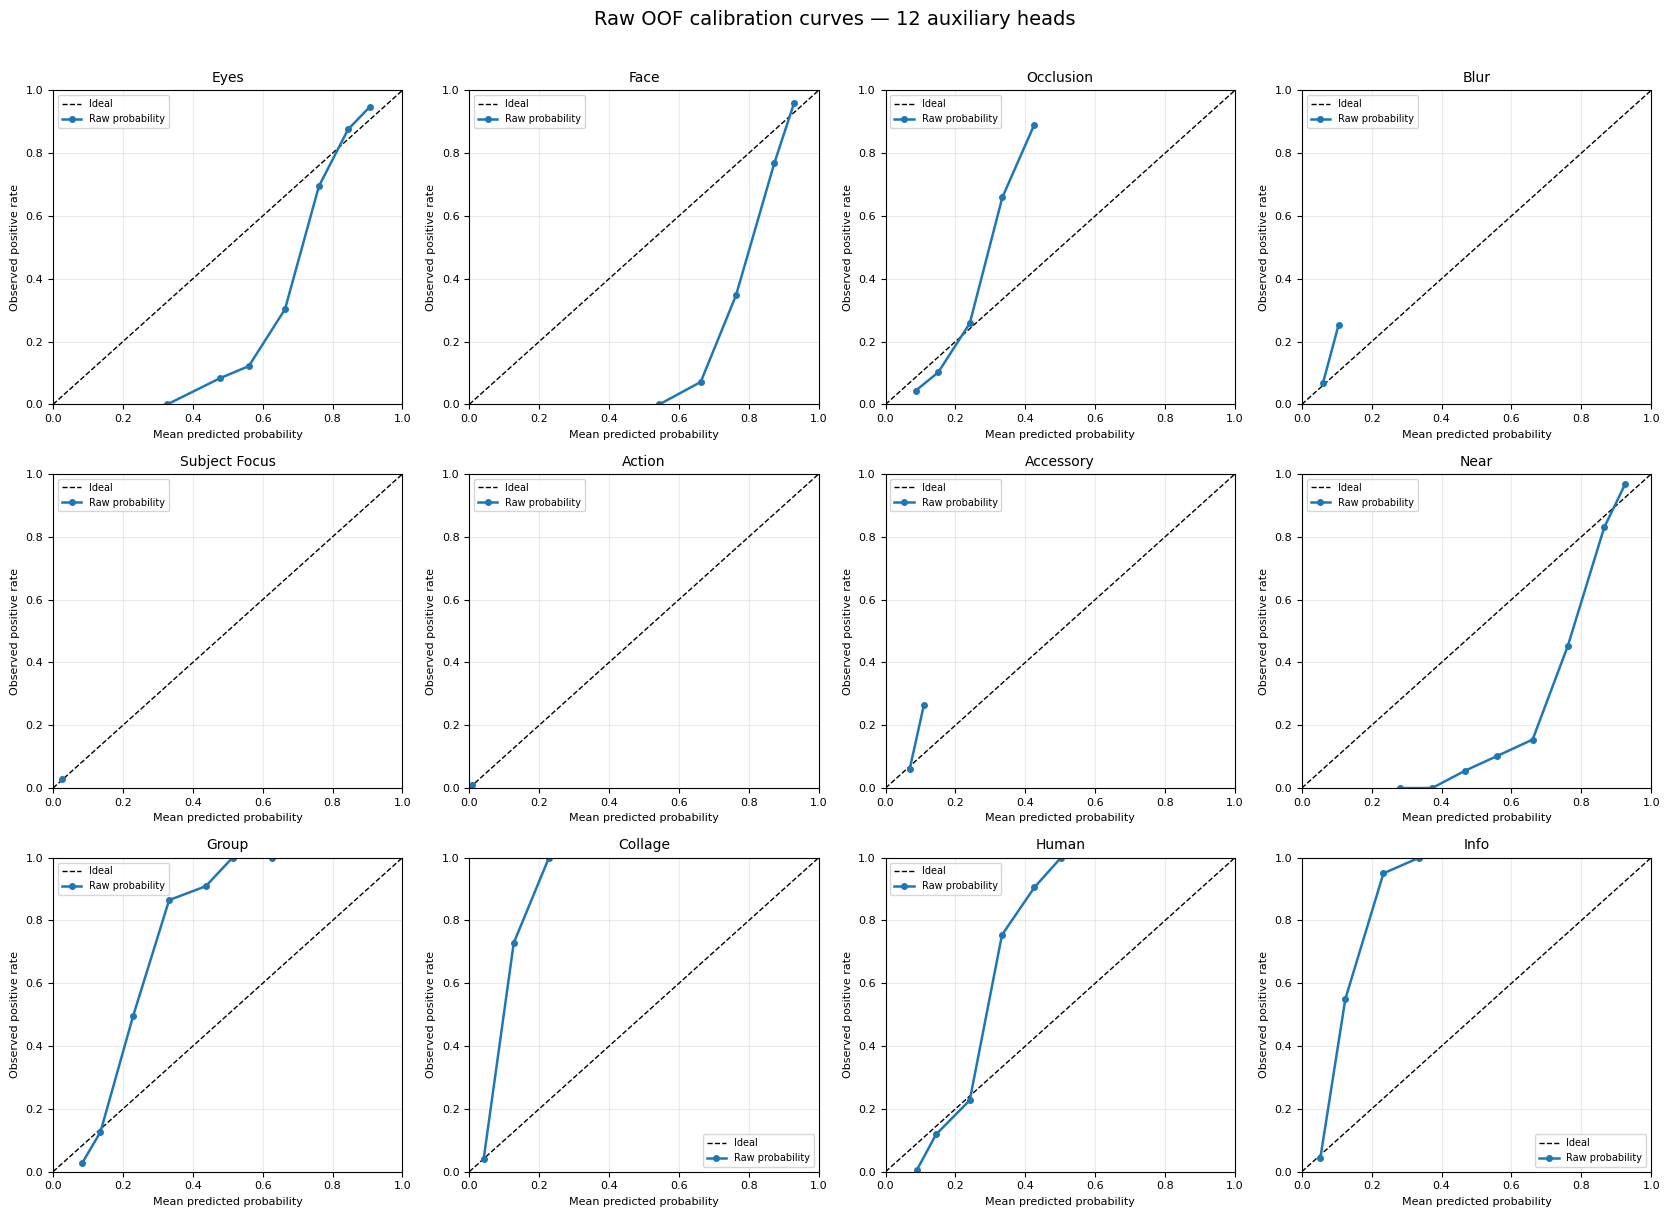

In [6]:
# =====================part4=======================================
# SECTION 2 — STEP 2A: Raw probability calibration diagnosis
#
#  feedback addressed:
# "Evaluate the calibration status of each label using:
#  1. Calibration curve
#  2. Brier score
#  3. Expected Calibration Error (ECE)"
#
# Uses:
# - all 12 auxiliary heads
# - all pooled OOF records
# 
#
# ============================================================

from src.aux_calibration import (
    diagnose_raw_oof_calibration,
    plot_calibration_curves,
)

# All 12 heads are analysed first.
# We will decide later which labels are usable for user-facing feedback.
CALIBRATION_TASKS = AUX_TASKS.copy()

raw_calibration_summary, raw_bin_tables = (
    diagnose_raw_oof_calibration(
        aux_df=aux_df,
        aux_tasks=CALIBRATION_TASKS,
        n_bins=10,
    )
)

# Sort worst-to-best by raw ECE only for inspection.
# This is not a final decision rule because ECE can be unstable for
# extremely rare labels; the calibration curve and Brier score matter too.
raw_calibration_summary = raw_calibration_summary.sort_values(
    "raw_ece",
    ascending=False,
).reset_index(drop=True)

print("Raw OOF calibration summary for all 12 auxiliary heads:")
display(raw_calibration_summary.round(4))

plot_calibration_curves(
    bin_tables=raw_bin_tables,
    aux_tasks=CALIBRATION_TASKS,
    title="Raw OOF calibration curves — 12 auxiliary heads",
    n_cols=4,
    method_label="Raw probability",
)

The raw reliability diagrams show that the auxiliary-head probabilities are not uniformly calibrated: some labels overestimate the positive rate while others underestimate it.

Each plotted point represents a probability bin with mean predicted probability on the x-axis and observed positive rate on the y-axis; perfect calibration lies on the dashed diagonal line.

In [7]:
# ===================== part 5 =====================================
# SECTION 2 — STEP 2B
# Split-aware calibration method selection
#
# Folds 1,2,3:
#   - choose raw / Platt / isotonic per auxiliary head
#   - produce cross-fitted selected probabilities for threshold search
#
# Folds 4,5:
#   - do NOT influence method selection
#   - receive probabilities from calibrators fitted only on folds 1,2,3
#
# No selective thresholds are chosen in this part.
# ================================================================

from src.aux_calibration import (
    crossfit_calibration_all_tasks,
    select_calibration_methods_all_tasks,
    fit_platt_calibrator,
    fit_isotonic_calibrator,
    apply_calibrator,
)

# ------------------------------------------------------------
# 0. Define the selection/evaluation split BEFORE method choice
# ------------------------------------------------------------

THRESHOLD_SELECTION_FOLDS = [1, 2, 3]
THRESHOLD_EVALUATION_FOLDS = [4, 5]

calibration_selection_aux_df = aux_df[
    aux_df["fold"].isin(THRESHOLD_SELECTION_FOLDS)
].copy()

calibration_evaluation_aux_df = aux_df[
    aux_df["fold"].isin(THRESHOLD_EVALUATION_FOLDS)
].copy()

print("Calibration-method selection samples:", len(calibration_selection_aux_df))
print("Final-evaluation samples:", len(calibration_evaluation_aux_df))


# ------------------------------------------------------------
# 1. Cross-fit calibration ONLY inside folds 1,2,3
# ------------------------------------------------------------

(
    calibration_probability_selection_df,
    calibration_results,
    bin_tables_by_task,
) = crossfit_calibration_all_tasks(
    aux_df=calibration_selection_aux_df,
    aux_tasks=CALIBRATION_TASKS,
    fold_col="fold",
    n_bins=10,
)

print(
    "\nCalibration comparison on selection folds only "
    "(raw / Platt / isotonic):"
)
display(calibration_results.round(6))


# ------------------------------------------------------------
# 2. Select one probability method per task using folds 1,2,3 only
# ------------------------------------------------------------

calibration_selection_df = select_calibration_methods_all_tasks(
    comparison_df=calibration_results,
    aux_tasks=CALIBRATION_TASKS,
    min_brier_improvement=0.0,
    min_ece_improvement=0.0,
)

print("\nSelected probability method per auxiliary head:")
display(calibration_selection_df.round(6))

SELECTED_METHODS = dict(
    zip(
        calibration_selection_df["task"],
        calibration_selection_df["selected_method"],
    )
)

print("\nSelected methods:")
print(SELECTED_METHODS)


# ------------------------------------------------------------
# 3. Build selected probabilities for folds 1,2,3
#
# These are cross-fitted within the selection folds.
# ------------------------------------------------------------

threshold_selection_df = calibration_probability_selection_df[
    ["Id", "fold"]
].copy()

for task in CALIBRATION_TASKS:
    threshold_selection_df[f"{task}_true"] = (
        calibration_probability_selection_df[f"{task}_true"]
    )

    method = SELECTED_METHODS[task]

    if method == "raw":
        source_col = f"{task}_prob_raw"
    elif method == "platt":
        source_col = f"{task}_prob_platt_cf"
    elif method == "isotonic":
        source_col = f"{task}_prob_isotonic_cf"
    else:
        raise ValueError(f"Unknown method for {task}: {method}")

    threshold_selection_df[f"{task}_prob_selected"] = (
        calibration_probability_selection_df[source_col]
    )


# ------------------------------------------------------------
# 4. Build selected probabilities for folds 4,5
#
# Fit final calibrators on folds 1,2,3 only.
# Apply them to folds 4,5.
# ------------------------------------------------------------

threshold_evaluation_df = calibration_evaluation_aux_df[
    ["Id", "fold"]
].copy()

for task in CALIBRATION_TASKS:
    true_col = f"{task}_true"
    prob_col = f"{task}_prob"

    threshold_evaluation_df[f"{task}_true"] = (
        calibration_evaluation_aux_df[true_col].to_numpy(dtype=int)
    )

    method = SELECTED_METHODS[task]

    y_fit = calibration_selection_aux_df[true_col].to_numpy(dtype=int)
    p_fit = calibration_selection_aux_df[prob_col].to_numpy(dtype=float)
    p_eval = calibration_evaluation_aux_df[prob_col].to_numpy(dtype=float)

    if method == "raw":
        selected_eval_prob = p_eval

    elif method == "platt":
        p_fit_clipped = np.clip(p_fit, 1e-7, 1 - 1e-7)
        p_eval_clipped = np.clip(p_eval, 1e-7, 1 - 1e-7)

        score_fit = np.log(p_fit_clipped / (1.0 - p_fit_clipped))
        score_eval = np.log(p_eval_clipped / (1.0 - p_eval_clipped))

        platt_model = fit_platt_calibrator(
            y_score_fit=score_fit,
            y_true_fit=y_fit,
        )

        selected_eval_prob = apply_calibrator(
            y_prob=score_eval,
            method="platt",
            calibrator=platt_model,
        )

    elif method == "isotonic":
        isotonic_model = fit_isotonic_calibrator(
            y_prob_fit=p_fit,
            y_true_fit=y_fit,
        )

        selected_eval_prob = apply_calibrator(
            y_prob=p_eval,
            method="isotonic",
            calibrator=isotonic_model,
        )

    else:
        raise ValueError(f"Unknown method for {task}: {method}")

    threshold_evaluation_df[f"{task}_prob_selected"] = selected_eval_prob


# ------------------------------------------------------------
# 5. Combine back into one dataframe for later parts
# ------------------------------------------------------------

aux_selected_df = pd.concat(
    [threshold_selection_df, threshold_evaluation_df],
    axis=0,
    ignore_index=True,
)

aux_selected_df = aux_selected_df.sort_values(["fold", "Id"]).reset_index(drop=True)

print("\nBuilt split-clean aux_selected_df.")
print("Threshold-selection samples:", len(threshold_selection_df))
print("Final-evaluation samples:", len(threshold_evaluation_df))
print("Total samples:", len(aux_selected_df))
display(aux_selected_df.head())

Calibration-method selection samples: 5948
Final-evaluation samples: 3964

Calibration comparison on selection folds only (raw / Platt / isotonic):


,task,method,n,positive_rate,brier,ece
0,Eyes,platt,5948,0.772360,0.146659,0.021474
1,Eyes,isotonic,5948,0.772360,0.149021,0.028619
2,Eyes,raw,5948,0.772360,0.158234,0.068026
3,Face,platt,5948,0.905010,0.068983,0.008712
4,Face,isotonic,5948,0.905010,0.069520,0.016726
5,Face,raw,5948,0.905010,0.076865,0.058107
6,Occlusion,isotonic,5948,0.172495,0.115877,0.015094
7,Occlusion,platt,5948,0.172495,0.118490,0.040870
8,Occlusion,raw,5948,0.172495,0.128459,0.054460
9,Blur,raw,5948,0.071284,0.066081,0.014441



Selected probability method per auxiliary head:


,task,selected_method,raw_brier,raw_ece,selected_brier,selected_ece,brier_improvement,ece_improvement
0,Eyes,platt,0.158234,0.068026,0.146659,0.021474,0.011576,0.046552
1,Face,platt,0.076865,0.058107,0.068983,0.008712,0.007882,0.049395
2,Occlusion,isotonic,0.128459,0.054460,0.115877,0.015094,0.012582,0.039366
3,Blur,raw,0.066081,0.014441,0.066081,0.014441,0.000000,0.000000
4,Subject Focus,raw,0.026336,0.003201,0.026336,0.003201,0.000000,0.000000
5,Action,platt,0.010324,0.001018,0.010316,0.000012,0.000008,0.001006
6,Accessory,raw,0.061262,0.020091,0.061262,0.020091,0.000000,0.000000
7,Near,platt,0.107336,0.081346,0.087402,0.010740,0.019934,0.070606
8,Group,platt,0.102850,0.044240,0.092452,0.011033,0.010398,0.033207
9,Collage,platt,0.047813,0.010428,0.043702,0.006013,0.004111,0.004415



Selected methods:
{'Eyes': 'platt', 'Face': 'platt', 'Occlusion': 'isotonic', 'Blur': 'raw', 'Subject Focus': 'raw', 'Action': 'platt', 'Accessory': 'raw', 'Near': 'platt', 'Group': 'platt', 'Collage': 'platt', 'Human': 'isotonic', 'Info': 'isotonic'}

Built split-clean aux_selected_df.
Threshold-selection samples: 5948
Final-evaluation samples: 3964
Total samples: 9912


,Id,fold,Eyes_true,Eyes_prob_selected,Face_true,Face_prob_selected,Occlusion_true,Occlusion_prob_selected,Blur_true,Blur_prob_selected,...,Near_true,Near_prob_selected,Group_true,Group_prob_selected,Collage_true,Collage_prob_selected,Human_true,Human_prob_selected,Info_true,Info_prob_selected
0,0007de18844b0dbbb5e1f607da0606e0,1,1,0.702406,1,0.951219,0,0.228477,0,0.066545,...,1,0.851416,1,0.068033,0,0.184331,0,0.362500,0,0.184615
1,0018df346ac9c1d8413cfcc888ca8246,1,1,0.453247,1,0.894473,0,0.228387,0,0.076648,...,1,0.916140,0,0.038009,0,0.053164,0,0.226500,0,0.056517
2,0042bc5bada6d1cf8951f8f9f0d399fa,1,1,0.508708,1,0.925396,0,0.094787,0,0.079685,...,1,0.902243,0,0.058878,0,0.042826,0,0.107527,0,0.041916
3,005017716086b8d5e118dd9fe26459b1,1,1,0.884340,1,0.988732,0,0.162055,0,0.060729,...,1,0.975346,0,0.029396,0,0.014125,0,0.100503,0,0.034586
4,00630b1262efe301cb15a3b2022ba744,1,1,0.591340,1,0.927929,0,0.035785,0,0.078894,...,1,0.636436,0,0.149696,0,0.033472,0,0.046338,0,0.034586


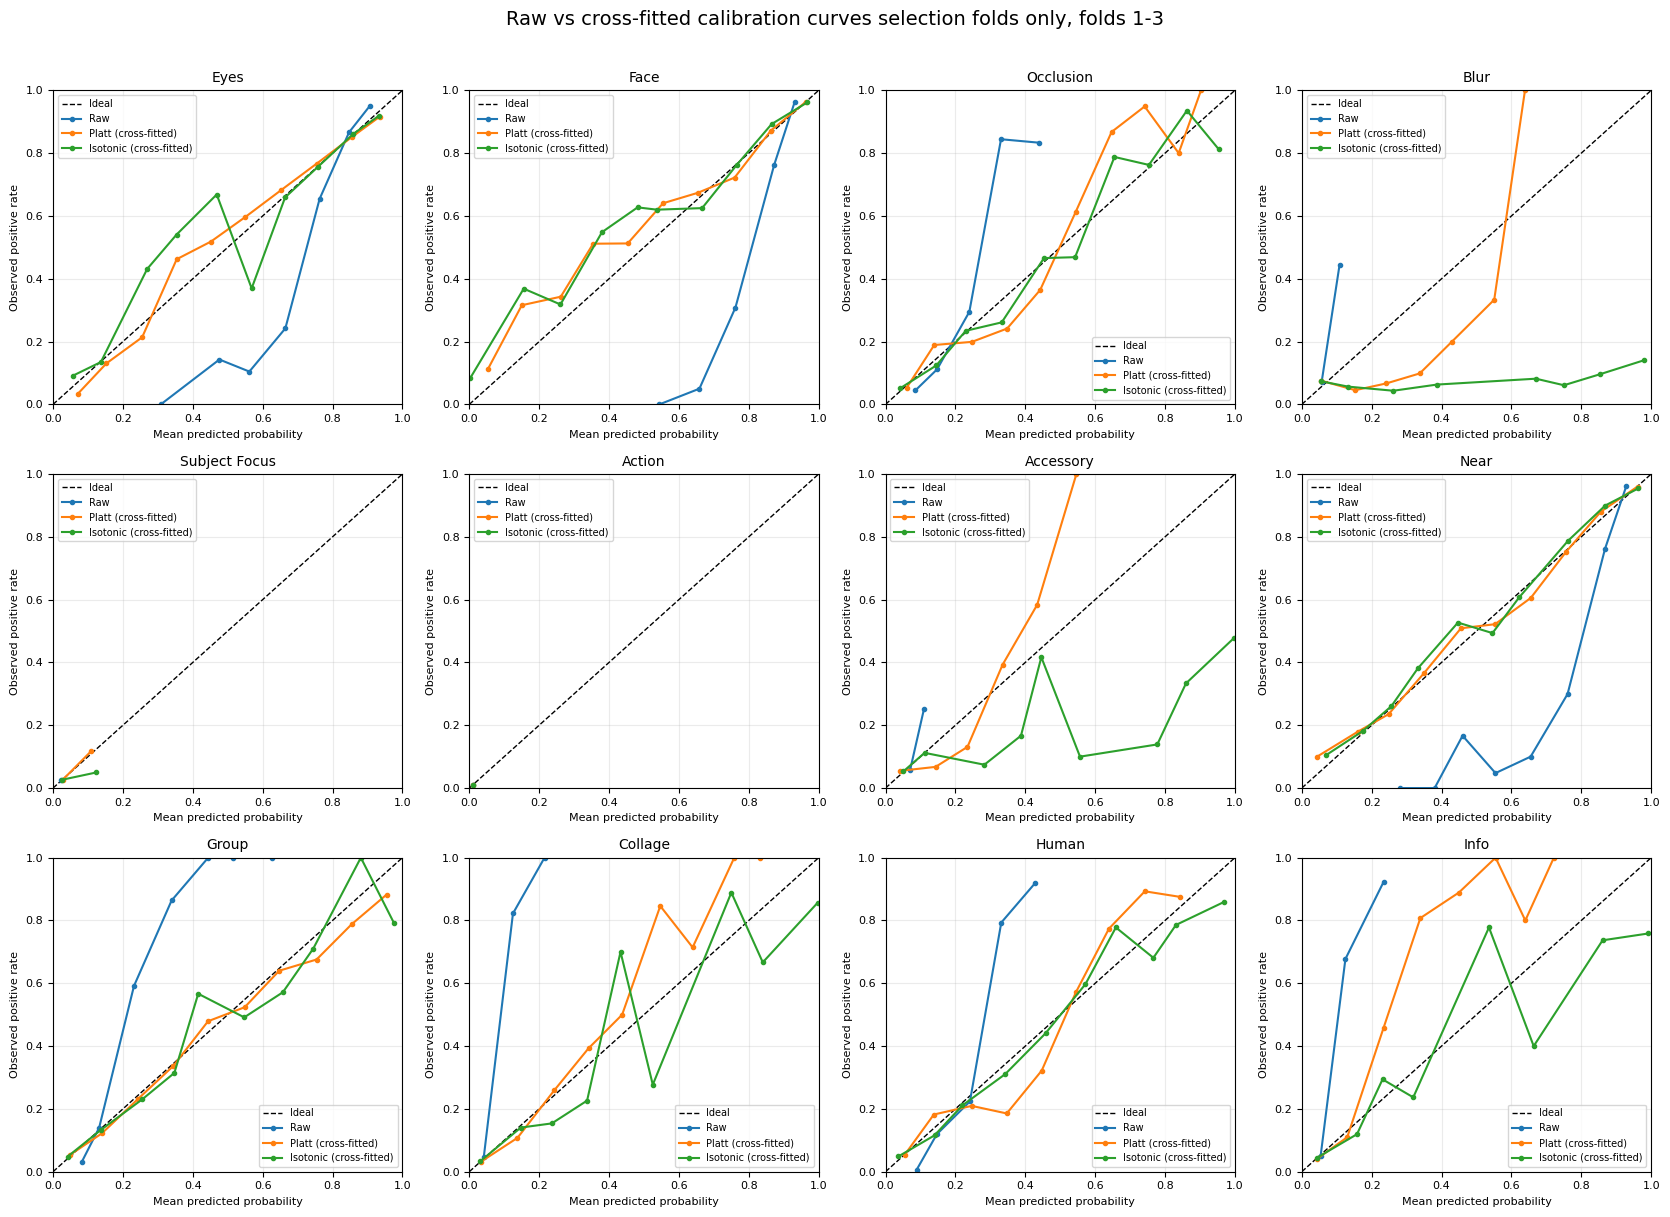

In [8]:
# ===================== part 6 =====================================
# SECTION 2 — STEP 2C
# Visual comparison of raw vs cross-fitted calibration
#
# Purpose:
# - Compare raw, Platt, and isotonic reliability curves.
# - Curves are computed on the calibration-method selection folds only.
# - Folds 4 and 5 are not used in this diagnostic.
# ================================================================

from src.aux_calibration import (
    plot_calibration_comparison,
)

plot_calibration_comparison(
    bin_tables_by_task=bin_tables_by_task,
    aux_tasks=CALIBRATION_TASKS,
    title=(
        "Raw vs cross-fitted calibration curves "
        "selection folds only, folds 1-3"
    ),
    n_cols=4,
)

In [9]:
# ===================== part 7 =====================================
# SECTION 3 — STEP 3A
# Verify fixed threshold-selection / evaluation split
# ================================================================

assert set(threshold_selection_df["fold"].unique()) == set(THRESHOLD_SELECTION_FOLDS)
assert set(threshold_evaluation_df["fold"].unique()) == set(THRESHOLD_EVALUATION_FOLDS)

assert len(threshold_selection_df) + len(threshold_evaluation_df) == len(aux_selected_df)

print("Threshold-selection samples:", len(threshold_selection_df))
print("Final-evaluation samples:", len(threshold_evaluation_df))

print(
    "\nThreshold-selection folds:",
    sorted(threshold_selection_df["fold"].unique().tolist()),
)

print(
    "Final-evaluation folds:",
    sorted(threshold_evaluation_df["fold"].unique().tolist()),
)

print("\nTotal samples:", len(threshold_selection_df) + len(threshold_evaluation_df))
print("Original samples:", len(aux_selected_df))

Threshold-selection samples: 5948
Final-evaluation samples: 3964

Threshold-selection folds: [1, 2, 3]
Final-evaluation folds: [4, 5]

Total samples: 9912
Original samples: 9912


In [10]:
# ===================== part 8 =====================================
# SECTION 4 — STEP 4A
# selective-prediction threshold-pair sweep
#
# Uses ONLY threshold-selection folds 1, 2, 3 records.
#
# Three regions:
#
#   p <= t_neg
#       -> negative feedback
#
#   t_neg < p < t_pos
#       -> abstain / no feedback
#
#   p >= t_pos
#       -> positive feedback
#
# Metrics:
#   PPV = reliability of displayed positive feedback
#   NPV = reliability of displayed negative feedback
#   selective_accuracy = correctness among all displayed feedback
#   coverage = fraction of samples receiving feedback
#
# No threshold is selected yet.
# ================================================================

import numpy as np
import pandas as pd


DISPLAY_THRESHOLD_GRID = np.round(
    np.arange(0.01, 1.00, 0.01),
    2,
)


selective_rows = []


for task in CALIBRATION_TASKS:

    y_true = threshold_selection_df[
        f"{task}_true"
    ].to_numpy(dtype=int)

    y_prob = threshold_selection_df[
        f"{task}_prob_selected"
    ].to_numpy(dtype=float)

    probability_method = SELECTED_METHODS[task]

    n_total = len(y_true)


    for negative_threshold in DISPLAY_THRESHOLD_GRID:

        for positive_threshold in DISPLAY_THRESHOLD_GRID:

            # Valid abstention interval requires:
            # t_neg < t_pos
            if negative_threshold >= positive_threshold:
                continue


            # ------------------------------------------------
            # Three selective-prediction regions
            # ------------------------------------------------

            negative_mask = (
                y_prob <= negative_threshold
            )

            positive_mask = (
                y_prob >= positive_threshold
            )

            displayed_mask = (
                negative_mask | positive_mask
            )

            abstain_mask = ~displayed_mask


            # ------------------------------------------------
            # Confusion counts for displayed feedback
            # ------------------------------------------------

            TN = int(
                (
                    negative_mask
                    & (y_true == 0)
                ).sum()
            )

            FN = int(
                (
                    negative_mask
                    & (y_true == 1)
                ).sum()
            )

            TP = int(
                (
                    positive_mask
                    & (y_true == 1)
                ).sum()
            )

            FP = int(
                (
                    positive_mask
                    & (y_true == 0)
                ).sum()
            )


            # ------------------------------------------------
            # Display counts
            # ------------------------------------------------

            n_negative_displayed = int(
                negative_mask.sum()
            )

            n_positive_displayed = int(
                positive_mask.sum()
            )

            n_displayed = int(
                displayed_mask.sum()
            )

            n_abstained = int(
                abstain_mask.sum()
            )


            # ------------------------------------------------
            # PPV
            #
            # Among displayed POSITIVE feedback:
            # how often is the label actually positive?
            # ------------------------------------------------

            PPV = (
                TP / (TP + FP)
                if (TP + FP) > 0
                else np.nan
            )


            # ------------------------------------------------
            # NPV
            #
            # Among displayed NEGATIVE feedback:
            # how often is the label actually negative?
            # ------------------------------------------------

            NPV = (
                TN / (TN + FN)
                if (TN + FN) > 0
                else np.nan
            )


            # ------------------------------------------------
            # Selective accuracy
            #
            # Correct feedback among all non-abstained cases
            # ------------------------------------------------

            selective_accuracy = (
                (TP + TN) / n_displayed
                if n_displayed > 0
                else np.nan
            )


            # ------------------------------------------------
            # Coverage
            # ------------------------------------------------

            negative_coverage = (
                n_negative_displayed / n_total
            )

            positive_coverage = (
                n_positive_displayed / n_total
            )

            coverage = (
                n_displayed / n_total
            )

            abstention_rate = (
                n_abstained / n_total
            )


            selective_rows.append({

                "task":
                    task,

                "probability_method":
                    probability_method,

                "negative_threshold":
                    negative_threshold,

                "positive_threshold":
                    positive_threshold,

                "n_total":
                    n_total,

                "n_negative_displayed":
                    n_negative_displayed,

                "n_positive_displayed":
                    n_positive_displayed,

                "n_displayed":
                    n_displayed,

                "n_abstained":
                    n_abstained,

                "negative_coverage":
                    negative_coverage,

                "positive_coverage":
                    positive_coverage,

                "coverage":
                    coverage,

                "abstention_rate":
                    abstention_rate,

                "PPV":
                    PPV,

                "NPV":
                    NPV,

                "selective_accuracy":
                    selective_accuracy,

                "TP":
                    TP,

                "FP":
                    FP,

                "TN":
                    TN,

                "FN":
                    FN,
            })


selective_threshold_sweep_df = (
    pd.DataFrame(selective_rows)
    .sort_values(
        [
            "task",
            "negative_threshold",
            "positive_threshold",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Candidate threshold pairs:",
    len(selective_threshold_sweep_df),
)

display(
    selective_threshold_sweep_df.head()
)



Candidate threshold pairs: 58212


,task,probability_method,negative_threshold,positive_threshold,n_total,n_negative_displayed,n_positive_displayed,n_displayed,n_abstained,negative_coverage,positive_coverage,coverage,abstention_rate,PPV,NPV,selective_accuracy,TP,FP,TN,FN
0,Accessory,raw,0.01,0.02,5948,0,5948,5948,0,0.0,1.000000,1.000000,0.000000,0.066913,NaN,0.066913,398,5550,0,0
1,Accessory,raw,0.01,0.03,5948,0,5948,5948,0,0.0,1.000000,1.000000,0.000000,0.066913,NaN,0.066913,398,5550,0,0
2,Accessory,raw,0.01,0.04,5948,0,5939,5939,9,0.0,0.998487,0.998487,0.001513,0.067015,NaN,0.067015,398,5541,0,0
3,Accessory,raw,0.01,0.05,5948,0,5467,5467,481,0.0,0.919132,0.919132,0.080868,0.071337,NaN,0.071337,390,5077,0,0
4,Accessory,raw,0.01,0.06,5948,0,4145,4145,1803,0.0,0.696873,0.696873,0.303127,0.082509,NaN,0.082509,342,3803,0,0


In [11]:
# ===================== part 9 =====================================
# SECTION 4 — STEP 4B
# Compare candidate reliability targets on the threshold-selection set
#
# Uses ONLY folds 1, 2, 3.
#
# For each reliability target r:
#
#   PPV >= r
#   NPV >= r
#
# Among feasible (t_neg, t_pos) pairs:
#   choose the pair with maximum coverage.
#
# Selective accuracy is used only as a tie-break.
#
# 
# No minimum directional-support requirement is imposed here.
# Directional counts are retained and will be examined later.
#
# Folds 4 and 5 are NOT used here.
# ================================================================

RELIABILITY_TARGETS = [
    0.80,
    0.85,
    0.90,
    0.95,
]


operating_point_rows = []


for task in CALIBRATION_TASKS:

    task_pairs = (
        selective_threshold_sweep_df[
            selective_threshold_sweep_df["task"] == task
        ]
        .copy()
    )

    probability_method = SELECTED_METHODS[task]


    for reliability_target in RELIABILITY_TARGETS:

        # ----------------------------------------------------
        # Joint reliability requirement
        # ----------------------------------------------------

        valid = task_pairs[
            (task_pairs["PPV"] >= reliability_target)
            &
            (task_pairs["NPV"] >= reliability_target)
        ].copy()


        # ----------------------------------------------------
        # No feasible pair
        # ----------------------------------------------------

        if len(valid) == 0:

            operating_point_rows.append({

                "task":
                    task,

                "probability_method":
                    probability_method,

                "reliability_target":
                    reliability_target,

                "selection_feasible":
                    False,

                "negative_threshold":
                    np.nan,

                "positive_threshold":
                    np.nan,

                "n_total":
                    len(threshold_selection_df),

                "n_negative_displayed":
                    0,

                "n_positive_displayed":
                    0,

                "n_displayed":
                    0,

                "n_abstained":
                    len(threshold_selection_df),

                "negative_coverage":
                    0.0,

                "positive_coverage":
                    0.0,

                "coverage":
                    0.0,

                "abstention_rate":
                    1.0,

                "PPV":
                    np.nan,

                "NPV":
                    np.nan,

                "selective_accuracy":
                    np.nan,

                "TP":
                    0,

                "FP":
                    0,

                "TN":
                    0,

                "FN":
                    0,
            })

            continue


        # ----------------------------------------------------
        # Primary objective:
        # maximize coverage.
        #
        # Tie-break:
        # maximize selective accuracy.
        # ----------------------------------------------------

        chosen = (
            valid
            .sort_values(
                [
                    "coverage",
                    "selective_accuracy",
                ],
                ascending=[
                    False,
                    False,
                ],
            )
            .iloc[0]
        )


        operating_point_rows.append({

            "task":
                task,

            "probability_method":
                probability_method,

            "reliability_target":
                reliability_target,

            "selection_feasible":
                True,

            "negative_threshold":
                chosen["negative_threshold"],

            "positive_threshold":
                chosen["positive_threshold"],

            "n_total":
                int(chosen["n_total"]),

            "n_negative_displayed":
                int(chosen["n_negative_displayed"]),

            "n_positive_displayed":
                int(chosen["n_positive_displayed"]),

            "n_displayed":
                int(chosen["n_displayed"]),

            "n_abstained":
                int(chosen["n_abstained"]),

            "negative_coverage":
                chosen["negative_coverage"],

            "positive_coverage":
                chosen["positive_coverage"],

            "coverage":
                chosen["coverage"],

            "abstention_rate":
                chosen["abstention_rate"],

            "PPV":
                chosen["PPV"],

            "NPV":
                chosen["NPV"],

            "selective_accuracy":
                chosen["selective_accuracy"],

            "TP":
                int(chosen["TP"]),

            "FP":
                int(chosen["FP"]),

            "TN":
                int(chosen["TN"]),

            "FN":
                int(chosen["FN"]),
        })


operating_points_df = (
    pd.DataFrame(operating_point_rows)
    .sort_values(
        [
            "task",
            "reliability_target",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Candidate operating points selected "
    "using folds 1–3 only:"
)


display(
    operating_points_df[
        [
            "task",
            "probability_method",
            "reliability_target",
            "selection_feasible",

            "negative_threshold",
            "positive_threshold",

            "n_negative_displayed",
            "n_positive_displayed",

            "negative_coverage",
            "positive_coverage",

            "PPV",
            "NPV",

            "coverage",
            "abstention_rate",
            "selective_accuracy",
        ]
    ].round(4)
)

Candidate operating points selected using folds 1–3 only:


,task,probability_method,reliability_target,selection_feasible,negative_threshold,positive_threshold,n_negative_displayed,n_positive_displayed,negative_coverage,positive_coverage,PPV,NPV,coverage,abstention_rate,selective_accuracy
0,Accessory,raw,0.80,True,0.14,0.15,5940,3,0.9987,0.0005,1.0000,0.9343,0.9992,0.0008,0.9344
1,Accessory,raw,0.85,True,0.14,0.15,5940,3,0.9987,0.0005,1.0000,0.9343,0.9992,0.0008,0.9344
2,Accessory,raw,0.90,True,0.14,0.15,5940,3,0.9987,0.0005,1.0000,0.9343,0.9992,0.0008,0.9344
3,Accessory,raw,0.95,True,0.09,0.14,5048,8,0.8487,0.0013,1.0000,0.9505,0.8500,0.1500,0.9506
4,Action,platt,0.80,False,NaN,NaN,0,0,0.0000,0.0000,NaN,NaN,0.0000,1.0000,NaN
5,Action,platt,0.85,False,NaN,NaN,0,0,0.0000,0.0000,NaN,NaN,0.0000,1.0000,NaN
6,Action,platt,0.90,False,NaN,NaN,0,0,0.0000,0.0000,NaN,NaN,0.0000,1.0000,NaN
7,Action,platt,0.95,False,NaN,NaN,0,0,0.0000,0.0000,NaN,NaN,0.0000,1.0000,NaN
8,Blur,raw,0.80,True,0.11,0.12,5945,1,0.9995,0.0002,1.0000,0.9290,0.9997,0.0003,0.9290
9,Blur,raw,0.85,True,0.11,0.12,5945,1,0.9995,0.0002,1.0000,0.9290,0.9997,0.0003,0.9290


Reliability target vs PPV, NPV, and coverage (threshold-selection folds 1–3 only):


,reliability_target,n_tasks_feasible,mean_PPV,median_PPV,mean_NPV,median_NPV,mean_coverage,median_coverage
0,0.80,10,0.8731,0.8547,0.8868,0.8889,0.9996,0.9998
1,0.85,9,0.9042,0.8788,0.8959,0.9054,0.9726,0.9997
2,0.90,8,0.9371,0.9181,0.9212,0.9217,0.8629,0.9688
3,0.95,7,0.9725,0.9552,0.9625,0.9515,0.5484,0.5476


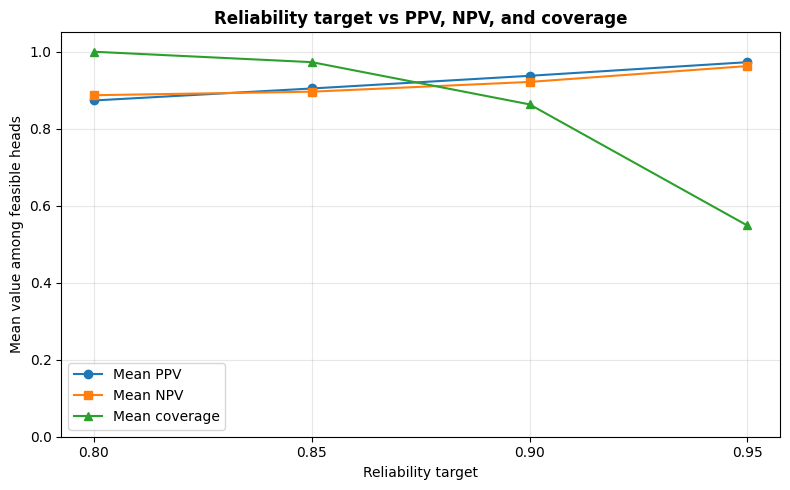

In [12]:
# ===================== part 9A====================================
# Reliability target vs PPV, NPV, and coverage
#
# 
# - Show the direct trade-off between reliability and coverage.
# - PPV summarizes positive-feedback reliability.
# - NPV summarizes negative-feedback reliability.
# - Coverage shows how often the selective policy gives feedback.
# ================================================================
import matplotlib.pyplot as plt

target_metric_rows = []

for target in sorted(
    operating_points_df["reliability_target"].unique()
):

    target_df = operating_points_df[
        operating_points_df["reliability_target"] == target
    ].copy()

    feasible_df = target_df[
        target_df["selection_feasible"]
    ].copy()

    target_metric_rows.append({

        "reliability_target":
            target,

        "n_tasks_feasible":
            int(feasible_df["task"].nunique()),

        "mean_PPV":
            feasible_df["PPV"].mean(),

        "median_PPV":
            feasible_df["PPV"].median(),

        "mean_NPV":
            feasible_df["NPV"].mean(),

        "median_NPV":
            feasible_df["NPV"].median(),

        "mean_coverage":
            feasible_df["coverage"].mean(),

        "median_coverage":
            feasible_df["coverage"].median(),
    })


target_metric_df = (
    pd.DataFrame(target_metric_rows)
    .sort_values("reliability_target")
    .reset_index(drop=True)
)

print(
    "Reliability target vs PPV, NPV, and coverage "
    "(threshold-selection folds 1–3 only):"
)

display(
    target_metric_df.round(4)
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    target_metric_df["reliability_target"],
    target_metric_df["mean_PPV"],
    marker="o",
    label="Mean PPV",
)

ax.plot(
    target_metric_df["reliability_target"],
    target_metric_df["mean_NPV"],
    marker="s",
    label="Mean NPV",
)

ax.plot(
    target_metric_df["reliability_target"],
    target_metric_df["mean_coverage"],
    marker="^",
    label="Mean coverage",
)


ax.set_title(
    "Reliability target vs PPV, NPV, and coverage",
    fontweight="bold",
)

ax.set_xlabel(
    "Reliability target"
)

ax.set_ylabel(
    "Mean value among feasible heads"
)

ax.set_xticks(
    target_metric_df["reliability_target"]
)

ax.set_ylim(
    0,
    1.05,
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# ===================== part 10 ====================================
# SECTION 4 — STEP 4C
# Freeze the final reliability target and operating points
#
# 
# - Uses ONLY the threshold-selection results from folds 1, 2, 3.
# - No information from folds 4, 5 is used.
# - Thresholds selected here must NOT be changed after evaluation.
# ================================================================

FINAL_RELIABILITY_TARGET = 0.90


selected_operating_points_df = (
    operating_points_df[
        operating_points_df["reliability_target"]
        == FINAL_RELIABILITY_TARGET
    ]
    .copy()
    .sort_values("task")
    .reset_index(drop=True)
)


print(
    "Frozen selective-feedback operating points "
    f"for reliability target = {FINAL_RELIABILITY_TARGET:.2f}"
)


display(
    selected_operating_points_df[
        [
            "task",
            "probability_method",
            "selection_feasible",

            "negative_threshold",
            "positive_threshold",

            "n_negative_displayed",
            "n_positive_displayed",

            "negative_coverage",
            "positive_coverage",

            "PPV",
            "NPV",

            "coverage",
            "abstention_rate",
            "selective_accuracy",
        ]
    ].round(4)
)

Frozen selective-feedback operating points for reliability target = 0.90


,task,probability_method,selection_feasible,negative_threshold,positive_threshold,n_negative_displayed,n_positive_displayed,negative_coverage,positive_coverage,PPV,NPV,coverage,abstention_rate,selective_accuracy
0,Accessory,raw,True,0.14,0.15,5940,3,0.9987,0.0005,1.0000,0.9343,0.9992,0.0008,0.9344
1,Action,platt,False,NaN,NaN,0,0,0.0000,0.0000,NaN,NaN,0.0000,1.0000,NaN
2,Blur,raw,True,0.11,0.12,5945,1,0.9995,0.0002,1.0000,0.9290,0.9997,0.0003,0.9290
3,Collage,platt,True,0.62,0.63,5935,13,0.9978,0.0022,0.9231,0.9493,1.0000,0.0000,0.9492
4,Eyes,platt,True,0.18,0.87,84,2263,0.0141,0.3805,0.9010,0.9286,0.3946,0.6054,0.9020
5,Face,platt,True,0.08,0.09,23,5924,0.0039,0.9960,0.9083,0.9130,0.9998,0.0002,0.9084
6,Group,platt,True,0.41,0.93,5559,23,0.9346,0.0039,0.9130,0.9007,0.9385,0.0615,0.9008
7,Human,isotonic,True,0.21,0.95,3741,60,0.6290,0.0101,0.9500,0.9147,0.6390,0.3610,0.9153
8,Info,isotonic,False,NaN,NaN,0,0,0.0000,0.0000,NaN,NaN,0.0000,1.0000,NaN
9,Near,platt,True,0.13,0.54,80,5468,0.0134,0.9193,0.9014,0.9000,0.9328,0.0672,0.9014


In [14]:
# =====================part 11 ====================================
# SECTION 4 — STEP 4D
# Held-out evaluation of the frozen selective-feedback thresholds
#
# Uses ONLY folds 4 and 5.
#
# 
# - Thresholds come from part 10.
# - No threshold search occurs here.
# - No thresholds are changed here.
#
# Three regions:
#
#   p <= t_neg
#       -> negative feedback
#
#   t_neg < p < t_pos
#       -> abstain / no feedback
#
#   p >= t_pos
#       -> positive feedback
#
# ================================================================

evaluation_rows = []


for row in selected_operating_points_df.itertuples(index=False):

    task = row.task
    method = row.probability_method
    feasible = bool(row.selection_feasible)


    # ------------------------------------------------------------
    # No feasible policy was found on folds 1–3
    # ------------------------------------------------------------

    if not feasible:

        evaluation_rows.append({

            "task":
                task,

            "probability_method":
                method,

            "selection_feasible":
                False,

            "negative_threshold":
                np.nan,

            "positive_threshold":
                np.nan,

            "n_total":
                len(threshold_evaluation_df),

            "n_negative_displayed":
                0,

            "n_positive_displayed":
                0,

            "n_displayed":
                0,

            "n_abstained":
                len(threshold_evaluation_df),

            "negative_coverage":
                0.0,

            "positive_coverage":
                0.0,

            "coverage":
                0.0,

            "abstention_rate":
                1.0,

            "PPV":
                np.nan,

            "NPV":
                np.nan,

            "selective_accuracy":
                np.nan,

            "TP":
                0,

            "FP":
                0,

            "TN":
                0,

            "FN":
                0,
        })

        continue


    # ------------------------------------------------------------
    # Frozen thresholds selected from folds 1–3
    # ------------------------------------------------------------

    t_neg = float(row.negative_threshold)
    t_pos = float(row.positive_threshold)


    y_true = threshold_evaluation_df[
        f"{task}_true"
    ].to_numpy(dtype=int)

    y_prob = threshold_evaluation_df[
        f"{task}_prob_selected"
    ].to_numpy(dtype=float)


    # ------------------------------------------------------------
    # Apply frozen selective-prediction regions
    # ------------------------------------------------------------

    negative_mask = (
        y_prob <= t_neg
    )

    positive_mask = (
        y_prob >= t_pos
    )

    displayed_mask = (
        negative_mask | positive_mask
    )

    abstain_mask = ~displayed_mask


    # ------------------------------------------------------------
    # Confusion counts
    # ------------------------------------------------------------

    TN = int(
        (
            negative_mask
            & (y_true == 0)
        ).sum()
    )

    FN = int(
        (
            negative_mask
            & (y_true == 1)
        ).sum()
    )

    TP = int(
        (
            positive_mask
            & (y_true == 1)
        ).sum()
    )

    FP = int(
        (
            positive_mask
            & (y_true == 0)
        ).sum()
    )


    # ------------------------------------------------------------
    # Display counts
    # ------------------------------------------------------------

    n_total = len(y_true)

    n_negative_displayed = int(
        negative_mask.sum()
    )

    n_positive_displayed = int(
        positive_mask.sum()
    )

    n_displayed = int(
        displayed_mask.sum()
    )

    n_abstained = int(
        abstain_mask.sum()
    )


    # ------------------------------------------------------------
    # PPV / NPV
    # ------------------------------------------------------------

    PPV = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else np.nan
    )

    NPV = (
        TN / (TN + FN)
        if (TN + FN) > 0
        else np.nan
    )


    # ------------------------------------------------------------
    # Selective accuracy
    # ------------------------------------------------------------

    selective_accuracy = (
        (TP + TN) / n_displayed
        if n_displayed > 0
        else np.nan
    )


    # ------------------------------------------------------------
    # Coverage
    # ------------------------------------------------------------

    negative_coverage = (
        n_negative_displayed / n_total
    )

    positive_coverage = (
        n_positive_displayed / n_total
    )

    coverage = (
        n_displayed / n_total
    )

    abstention_rate = (
        n_abstained / n_total
    )


    evaluation_rows.append({

        "task":
            task,

        "probability_method":
            method,

        "selection_feasible":
            True,

        "negative_threshold":
            t_neg,

        "positive_threshold":
            t_pos,

        "n_total":
            n_total,

        "n_negative_displayed":
            n_negative_displayed,

        "n_positive_displayed":
            n_positive_displayed,

        "n_displayed":
            n_displayed,

        "n_abstained":
            n_abstained,

        "negative_coverage":
            negative_coverage,

        "positive_coverage":
            positive_coverage,

        "coverage":
            coverage,

        "abstention_rate":
            abstention_rate,

        "PPV":
            PPV,

        "NPV":
            NPV,

        "selective_accuracy":
            selective_accuracy,

        "TP":
            TP,

        "FP":
            FP,

        "TN":
            TN,

        "FN":
            FN,
    })


evaluation_df = (
    pd.DataFrame(evaluation_rows)
    .sort_values("task")
    .reset_index(drop=True)
)


print(
    "Held-out evaluation of frozen thresholds "
    "on folds 4–5:"
)


display(
    evaluation_df[
        [
            "task",
            "probability_method",
            "selection_feasible",

            "negative_threshold",
            "positive_threshold",

            "n_negative_displayed",
            "n_positive_displayed",

            "negative_coverage",
            "positive_coverage",

            "PPV",
            "NPV",

            "coverage",
            "abstention_rate",
            "selective_accuracy",

            "TP",
            "FP",
            "TN",
            "FN",
        ]
    ].round(4)
)

Held-out evaluation of frozen thresholds on folds 4–5:


,task,probability_method,selection_feasible,negative_threshold,positive_threshold,n_negative_displayed,n_positive_displayed,negative_coverage,positive_coverage,PPV,NPV,coverage,abstention_rate,selective_accuracy,TP,FP,TN,FN
0,Accessory,raw,True,0.14,0.15,3964,0,1.0000,0.0000,NaN,0.9309,1.0000,0.0000,0.9309,0,0,3690,274
1,Action,platt,False,NaN,NaN,0,0,0.0000,0.0000,NaN,NaN,0.0000,1.0000,NaN,0,0,0,0
2,Blur,raw,True,0.11,0.12,3954,1,0.9975,0.0003,0.0000,0.9317,0.9977,0.0023,0.9315,0,1,3684,270
3,Collage,platt,True,0.62,0.63,3930,34,0.9914,0.0086,0.9118,0.9623,1.0000,0.0000,0.9619,31,3,3782,148
4,Eyes,platt,True,0.18,0.87,62,787,0.0156,0.1985,0.9377,0.8710,0.2142,0.7858,0.9329,738,49,54,8
5,Face,platt,True,0.08,0.09,2,3961,0.0005,0.9992,0.9031,1.0000,0.9997,0.0003,0.9031,3577,384,2,0
6,Group,platt,True,0.41,0.93,3520,4,0.8880,0.0010,0.7500,0.9159,0.8890,0.1110,0.9157,3,1,3224,296
7,Human,isotonic,True,0.21,0.95,2522,66,0.6362,0.0166,0.8333,0.9144,0.6529,0.3471,0.9123,55,11,2306,216
8,Info,isotonic,False,NaN,NaN,0,0,0.0000,0.0000,NaN,NaN,0.0000,1.0000,NaN,0,0,0,0
9,Near,platt,True,0.13,0.54,132,3281,0.0333,0.8277,0.9393,0.8409,0.8610,0.1390,0.9355,3082,199,111,21


> NaN is shown because the task/head of Focus and Action do not fall under the reliable region 

In [15]:
# =====================  13 ====================================
# SECTION 4 — STEP 4F
# Compare threshold-selection performance with held-out performance
#
# 
# - Show whether the frozen operating point generalizes.
# - Compare PPV, NPV, coverage, and directional support.
#
# No threshold modification occurs here.
# ================================================================

selection_eval_rows = []


for task in CALIBRATION_TASKS:

    # ------------------------------------------------------------
    # Selection-set result: folds 1, 2, 3
    # ------------------------------------------------------------

    sel = selected_operating_points_df[
        selected_operating_points_df["task"] == task
    ].iloc[0]


    # ------------------------------------------------------------
    # Held-out result: folds 4, 5
    # ------------------------------------------------------------

    ev = evaluation_df[
        evaluation_df["task"] == task
    ].iloc[0]


    selection_eval_rows.append({

        "task":
            task,

        "probability_method":
            sel["probability_method"],

        "selection_feasible":
            bool(sel["selection_feasible"]),

        "negative_threshold":
            sel["negative_threshold"],

        "positive_threshold":
            sel["positive_threshold"],


        # ---------------- Selection ----------------

        "selection_PPV":
            sel["PPV"],

        "evaluation_PPV":
            ev["PPV"],

        "PPV_change":
            (
                ev["PPV"] - sel["PPV"]
                if (
                    not pd.isna(ev["PPV"])
                    and not pd.isna(sel["PPV"])
                )
                else np.nan
            ),


        "selection_NPV":
            sel["NPV"],

        "evaluation_NPV":
            ev["NPV"],

        "NPV_change":
            (
                ev["NPV"] - sel["NPV"]
                if (
                    not pd.isna(ev["NPV"])
                    and not pd.isna(sel["NPV"])
                )
                else np.nan
            ),


        # ---------------- Coverage ----------------

        "selection_coverage":
            sel["coverage"],

        "evaluation_coverage":
            ev["coverage"],

        "coverage_change":
            (
                ev["coverage"]
                - sel["coverage"]
            ),


        # ---------------- Directional support ----------------

        "selection_n_positive":
            int(sel["n_positive_displayed"]),

        "evaluation_n_positive":
            int(ev["n_positive_displayed"]),

        "selection_n_negative":
            int(sel["n_negative_displayed"]),

        "evaluation_n_negative":
            int(ev["n_negative_displayed"]),
    })


selection_vs_evaluation_df = (
    pd.DataFrame(selection_eval_rows)
    .sort_values("task")
    .reset_index(drop=True)
)


print(
    "Selection-set vs held-out generalization:"
)


display(
    selection_vs_evaluation_df[
        [
            "task",

            "negative_threshold",
            "positive_threshold",

            "selection_PPV",
            "evaluation_PPV",
            "PPV_change",

            "selection_NPV",
            "evaluation_NPV",
            "NPV_change",

            "selection_coverage",
            "evaluation_coverage",
            "coverage_change",

            "selection_n_positive",
            "evaluation_n_positive",

            "selection_n_negative",
            "evaluation_n_negative",
        ]
    ].round(4)
)

Selection-set vs held-out generalization:


,task,negative_threshold,positive_threshold,selection_PPV,evaluation_PPV,PPV_change,selection_NPV,evaluation_NPV,NPV_change,selection_coverage,evaluation_coverage,coverage_change,selection_n_positive,evaluation_n_positive,selection_n_negative,evaluation_n_negative
0,Accessory,0.14,0.15,1.0000,NaN,NaN,0.9343,0.9309,-0.0035,0.9992,1.0000,0.0008,3,0,5940,3964
1,Action,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0,0,0,0
2,Blur,0.11,0.12,1.0000,0.0000,-1.0000,0.9290,0.9317,0.0027,0.9997,0.9977,-0.0019,1,1,5945,3954
3,Collage,0.62,0.63,0.9231,0.9118,-0.0113,0.9493,0.9623,0.0131,1.0000,1.0000,0.0000,13,34,5935,3930
4,Eyes,0.18,0.87,0.9010,0.9377,0.0367,0.9286,0.8710,-0.0576,0.3946,0.2142,-0.1804,2263,787,84,62
5,Face,0.08,0.09,0.9083,0.9031,-0.0053,0.9130,1.0000,0.0870,0.9998,0.9997,-0.0001,5924,3961,23,2
6,Group,0.41,0.93,0.9130,0.7500,-0.1630,0.9007,0.9159,0.0152,0.9385,0.8890,-0.0495,23,4,5559,3520
7,Human,0.21,0.95,0.9500,0.8333,-0.1167,0.9147,0.9144,-0.0004,0.6390,0.6529,0.0138,60,66,3741,2522
8,Info,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0,0,0,0
9,Near,0.13,0.54,0.9014,0.9393,0.0379,0.9000,0.8409,-0.0591,0.9328,0.8610,-0.0718,5468,3281,80,132


In [16]:
# ===================== part 16 ====================================
# SECTION 4 — STEP 4G
# Final selective-prediction reporting table
#
# This table summarizes:
# - frozen thresholds selected on folds 1–3
# - held-out results on folds 4–5
# - direction-specific point-estimate checks
#
# IMPORTANT:
# This part is descriptive/reporting only.
# It does NOT define new thresholds or retune the policy.
# ================================================================

final_results_df = (
    evaluation_df[
        [
            "task",
            "probability_method",
            "selection_feasible",

            "negative_threshold",
            "positive_threshold",

            "n_positive_displayed",
            "PPV",

            "n_negative_displayed",
            "NPV",

            "coverage",
            "abstention_rate",
            "selective_accuracy",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Direction-specific point-estimate checks
# ------------------------------------------------------------

final_results_df["positive_point_pass"] = (
    final_results_df["PPV"] >= FINAL_RELIABILITY_TARGET
)

final_results_df["negative_point_pass"] = (
    final_results_df["NPV"] >= FINAL_RELIABILITY_TARGET
)


# ------------------------------------------------------------
# Two-sided held-out point-estimate criterion
# ------------------------------------------------------------

final_results_df["two_sided_point_pass"] = (
    final_results_df["positive_point_pass"]
    &
    final_results_df["negative_point_pass"]
)


print(
    "Final held-out selective-prediction results "
    "(thresholds selected on folds 1–3; evaluated on folds 4–5):"
)


display(
    final_results_df[
        [
            "task",
            "probability_method",
            "selection_feasible",

            "negative_threshold",
            "positive_threshold",

            "n_positive_displayed",
            "PPV",
            "positive_point_pass",

            "n_negative_displayed",
            "NPV",
            "negative_point_pass",

            "coverage",
            "abstention_rate",
            "selective_accuracy",

            "two_sided_point_pass",
        ]
    ].round(4)
)

Final held-out selective-prediction results (thresholds selected on folds 1–3; evaluated on folds 4–5):


,task,probability_method,selection_feasible,negative_threshold,positive_threshold,n_positive_displayed,PPV,positive_point_pass,n_negative_displayed,NPV,negative_point_pass,coverage,abstention_rate,selective_accuracy,two_sided_point_pass
0,Accessory,raw,True,0.14,0.15,0,NaN,False,3964,0.9309,True,1.0000,0.0000,0.9309,False
1,Action,platt,False,NaN,NaN,0,NaN,False,0,NaN,False,0.0000,1.0000,NaN,False
2,Blur,raw,True,0.11,0.12,1,0.0000,False,3954,0.9317,True,0.9977,0.0023,0.9315,False
3,Collage,platt,True,0.62,0.63,34,0.9118,True,3930,0.9623,True,1.0000,0.0000,0.9619,True
4,Eyes,platt,True,0.18,0.87,787,0.9377,True,62,0.8710,False,0.2142,0.7858,0.9329,False
5,Face,platt,True,0.08,0.09,3961,0.9031,True,2,1.0000,True,0.9997,0.0003,0.9031,True
6,Group,platt,True,0.41,0.93,4,0.7500,False,3520,0.9159,True,0.8890,0.1110,0.9157,False
7,Human,isotonic,True,0.21,0.95,66,0.8333,False,2522,0.9144,True,0.6529,0.3471,0.9123,False
8,Info,isotonic,False,NaN,NaN,0,NaN,False,0,NaN,False,0.0000,1.0000,NaN,False
9,Near,platt,True,0.13,0.54,3281,0.9393,True,132,0.8409,False,0.8610,0.1390,0.9355,False


In [17]:
# ===================== part 17 ====================================
# SECTION 5 — STEP 5A
# Reconstruct split-clean calibration models for prototype testing
#
# Purpose:
# - The prototype model outputs RAW sigmoid probabilities.
# - The selective thresholds were defined on SELECTED/CALIBRATED probabilities.
# - Therefore raw model outputs must first be transformed using the
#   selected calibration method.
#
# Split-clean protocol:
# - Calibration methods were selected using folds 1,2,3.
# - Thresholds were selected using folds 1,2,3.
# - Folds 4,5 are final evaluation folds.
#
# Therefore, for prototype evaluation on folds 4,5:
#   fit calibrators on folds 1,2,3 only
#   apply calibrators to folds 4,5
#
# This must match the revised part 5 construction of threshold_evaluation_df.
# ================================================================

from src.aux_calibration import (
    fit_platt_calibrator,
    fit_isotonic_calibrator,
    apply_calibrator,
)


def probability_to_logit(prob):
    """
    Inverse-sigmoid transformation used for Platt-style calibration.
    """
    prob = np.asarray(prob, dtype=float)

    prob = np.clip(
        prob,
        1e-7,
        1.0 - 1e-7,
    )

    return np.log(
        prob / (1.0 - prob)
    )


# ------------------------------------------------------------
# Build calibrators for final-evaluation folds.
#
# 
# Both fold 4 and fold 5 use calibrators fitted only on folds 1,2,3.
# Fold 4 must not use fold 5.
# Fold 5 must not use fold 4.
# ------------------------------------------------------------

PROTOTYPE_EVAL_FOLDS = THRESHOLD_EVALUATION_FOLDS.copy()

calibration_fit_df = aux_df[
    aux_df["fold"].isin(THRESHOLD_SELECTION_FOLDS)
].copy()

fold_calibrators = {}

for heldout_fold in PROTOTYPE_EVAL_FOLDS:

    fold_calibrators[heldout_fold] = {}

    for task in CALIBRATION_TASKS:

        method = SELECTED_METHODS[task]

        y_true_fit = calibration_fit_df[
            f"{task}_true"
        ].to_numpy(dtype=int)

        raw_prob_fit = calibration_fit_df[
            f"{task}_prob"
        ].to_numpy(dtype=float)

        if method == "raw":

            calibrator = None

        elif method == "platt":

            logit_fit = probability_to_logit(
                raw_prob_fit
            )

            calibrator = fit_platt_calibrator(
                y_score_fit=logit_fit,
                y_true_fit=y_true_fit,
            )

        elif method == "isotonic":

            calibrator = fit_isotonic_calibrator(
                y_prob_fit=raw_prob_fit,
                y_true_fit=y_true_fit,
            )

        else:

            raise ValueError(
                f"Unknown calibration method for {task}: {method}"
            )

        fold_calibrators[heldout_fold][task] = calibrator


print(
    "Built split-clean calibrators for folds:",
    sorted(fold_calibrators.keys()),
)

print(
    "Calibrator fitting folds:",
    sorted(calibration_fit_df["fold"].unique().tolist()),
)


# ================================================================
# Verification:
# Reconstruct selected probabilities for folds 4,5 from raw OOF
# probabilities and compare with threshold_evaluation_df.
#
# Expected result:
# differences should be exactly 0 or very close to floating precision.
# ================================================================

verification_rows = []

for heldout_fold in PROTOTYPE_EVAL_FOLDS:

    for task in CALIBRATION_TASKS:

        method = SELECTED_METHODS[task]

        check_df = (
            aux_df.loc[
                aux_df["fold"] == heldout_fold,
                [
                    "Id",
                    f"{task}_prob",
                ],
            ]
            .merge(
                threshold_evaluation_df.loc[
                    threshold_evaluation_df["fold"] == heldout_fold,
                    [
                        "Id",
                        f"{task}_prob_selected",
                    ],
                ],
                on="Id",
                how="inner",
            )
        )

        raw_prob = check_df[
            f"{task}_prob"
        ].to_numpy(dtype=float)

        if method == "raw":

            reconstructed_prob = raw_prob

        elif method == "platt":

            raw_logit = probability_to_logit(
                raw_prob
            )

            reconstructed_prob = apply_calibrator(
                y_prob=raw_logit,
                method="platt",
                calibrator=fold_calibrators[
                    heldout_fold
                ][task],
            )

        elif method == "isotonic":

            reconstructed_prob = apply_calibrator(
                y_prob=raw_prob,
                method="isotonic",
                calibrator=fold_calibrators[
                    heldout_fold
                ][task],
            )

        else:

            raise ValueError(
                f"Unknown calibration method for {task}: {method}"
            )

        selected_prob = check_df[
            f"{task}_prob_selected"
        ].to_numpy(dtype=float)

        absolute_difference = np.abs(
            reconstructed_prob
            - selected_prob
        )

        verification_rows.append({

            "fold":
                heldout_fold,

            "task":
                task,

            "method":
                method,

            "n":
                len(check_df),

            "mean_abs_difference":
                float(absolute_difference.mean()),

            "max_abs_difference":
                float(absolute_difference.max()),
        })


calibration_reconstruction_check_df = (
    pd.DataFrame(verification_rows)
    .sort_values(
        ["fold", "task"]
    )
    .reset_index(drop=True)
)


print(
    "\nCalibration reconstruction check:"
)

display(
    calibration_reconstruction_check_df.round(10)
)

print(
    "\nOverall maximum absolute difference:",
    calibration_reconstruction_check_df[
        "max_abs_difference"
    ].max(),
)

assert (
    calibration_reconstruction_check_df[
        "max_abs_difference"
    ].max()
    < 1e-10
)

Built split-clean calibrators for folds: [4, 5]
Calibrator fitting folds: [1, 2, 3]

Calibration reconstruction check:


,fold,task,method,n,mean_abs_difference,max_abs_difference
0,4,Accessory,raw,1982,0.0,0.0
1,4,Action,platt,1982,0.0,0.0
2,4,Blur,raw,1982,0.0,0.0
3,4,Collage,platt,1982,0.0,0.0
4,4,Eyes,platt,1982,0.0,0.0
5,4,Face,platt,1982,0.0,0.0
6,4,Group,platt,1982,0.0,0.0
7,4,Human,isotonic,1982,0.0,0.0
8,4,Info,isotonic,1982,0.0,0.0
9,4,Near,platt,1982,0.0,0.0



Overall maximum absolute difference: 0.0


In [18]:
# ===================== part 18 ====================================
# SECTION 5 — STEP 5B
# Reusable calibration helper for raw auxiliary probabilities
#
# Input:
#   raw_probs = {
#       "Eyes": 0.82,
#       "Face": 0.91,
#       ...
#   }
#
# Output:
#   calibrated_probs = {
#       "Eyes": ...,
#       "Face": ...,
#       ...
#   }
#
# heldout_fold determines which fold-specific calibrator is used.
# ================================================================


def calibrate_aux_probabilities(
    raw_probs,
    heldout_fold,
    selected_methods=SELECTED_METHODS,
    calibrators_by_fold=fold_calibrators,
):
    """
    Convert raw auxiliary sigmoid probabilities into the calibrated
    probability space used by the selective-prediction thresholds.

    Parameters
    ----------
    raw_probs : dict
        {task: raw sigmoid probability}

    heldout_fold : int
        Evaluation fold whose split-clean calibrator should be used.

    Returns
    -------
    dict
        {task: calibrated probability}
    """

    if heldout_fold not in calibrators_by_fold:
        raise ValueError(
            f"No calibrators available for fold {heldout_fold}. "
            f"Available folds: {sorted(calibrators_by_fold.keys())}"
        )


    calibrated_probs = {}


    for task, raw_prob in raw_probs.items():

        if task not in selected_methods:
            raise KeyError(
                f"No selected calibration method for task: {task}"
            )

        method = selected_methods[task]

        raw_prob = float(raw_prob)


        # ----------------------------------------------------
        # RAW
        # ----------------------------------------------------

        if method == "raw":

            calibrated_prob = raw_prob


        # ----------------------------------------------------
        # PLATT
        # ----------------------------------------------------

        elif method == "platt":

            raw_logit = probability_to_logit(
                [raw_prob]
            )

            calibrated_prob = apply_calibrator(
                y_prob=raw_logit,
                method="platt",
                calibrator=calibrators_by_fold[
                    heldout_fold
                ][task],
            )[0]


        # ----------------------------------------------------
        # ISOTONIC
        # ----------------------------------------------------

        elif method == "isotonic":

            calibrated_prob = apply_calibrator(
                y_prob=np.array(
                    [raw_prob],
                    dtype=float,
                ),
                method="isotonic",
                calibrator=calibrators_by_fold[
                    heldout_fold
                ][task],
            )[0]


        else:

            raise ValueError(
                f"Unknown calibration method "
                f"for {task}: {method}"
            )


        calibrated_probs[task] = float(
            calibrated_prob
        )


    return calibrated_probs

# ================================================================
# Sanity check using one real OOF sample from fold 4
# ================================================================

CHECK_FOLD = 4


example_raw_row = (
    aux_df[
        aux_df["fold"] == CHECK_FOLD
    ]
    .iloc[0]
)


example_id = example_raw_row["Id"]


example_raw_probs = {
    task: float(
        example_raw_row[f"{task}_prob"]
    )
    for task in CALIBRATION_TASKS
}


example_calibrated_probs = (
    calibrate_aux_probabilities(
        raw_probs=example_raw_probs,
        heldout_fold=CHECK_FOLD,
    )
)


# Retrieve the already-created cross-fitted values
example_expected_row = (
    aux_selected_df[
        aux_selected_df["Id"] == example_id
    ]
    .iloc[0]
)


comparison_rows = []


for task in CALIBRATION_TASKS:

    expected = float(
        example_expected_row[
            f"{task}_prob_selected"
        ]
    )

    reconstructed = float(
        example_calibrated_probs[task]
    )


    comparison_rows.append({

        "task":
            task,

        "method":
            SELECTED_METHODS[task],

        "raw_probability":
            example_raw_probs[task],

        "calibrated_probability":
            reconstructed,

        "expected_probability":
            expected,

        "absolute_difference":
            abs(
                reconstructed - expected
            ),
    })


prototype_calibration_check_df = (
    pd.DataFrame(comparison_rows)
)


print(
    "Example OOF ID:",
    example_id,
)

print(
    "Held-out fold:",
    CHECK_FOLD,
)


display(
    prototype_calibration_check_df.round(10)
)


print(
    "\nMaximum absolute difference:",
    prototype_calibration_check_df[
        "absolute_difference"
    ].max(),
)

Example OOF ID: 0023b8a3abc93c712edd6120867deb53
Held-out fold: 4


,task,method,raw_probability,calibrated_probability,expected_probability,absolute_difference
0,Eyes,platt,0.788930,0.715252,0.715252,0.0
1,Face,platt,0.919535,0.944282,0.944282,0.0
2,Occlusion,isotonic,0.297645,0.726027,0.726027,0.0
3,Blur,raw,0.048647,0.048647,0.048647,0.0
4,Subject Focus,raw,0.015538,0.015538,0.015538,0.0
5,Action,platt,0.008254,0.010530,0.010530,0.0
6,Accessory,raw,0.065064,0.065064,0.065064,0.0
7,Near,platt,0.892092,0.876848,0.876848,0.0
8,Group,platt,0.077334,0.022323,0.022323,0.0
9,Collage,platt,0.058802,0.102275,0.102275,0.0



Maximum absolute difference: 0.0


In [19]:
# ===================== part 19 ====================================
# SECTION 5 — STEP 5C
# Apply the frozen selective-prediction policy
#
# Input:
#   selected auxiliary probabilities
#
# Output per task:
#   "negative"
#   "abstain"
#   "positive"
#
# 
# - Uses the frozen thresholds selected on folds 1–3.
# - Does NOT use the old F1 uncertainty band.
# - Does NOT retune thresholds using folds 4–5.
# ================================================================


def build_selective_policy(
    operating_points_df,
):
    """
    Convert the frozen operating-point dataframe into a
    task -> policy dictionary.
    """

    policy = {}

    for row in operating_points_df.itertuples(index=False):

        if not bool(row.selection_feasible):

            policy[row.task] = {
                "selection_feasible": False,
                "negative_threshold": None,
                "positive_threshold": None,
            }

        else:

            policy[row.task] = {
                "selection_feasible": True,
                "negative_threshold": float(
                    row.negative_threshold
                ),
                "positive_threshold": float(
                    row.positive_threshold
                ),
            }

    return policy


SELECTIVE_POLICY = build_selective_policy(
    selected_operating_points_df
)


def selective_state(
    probability,
    task,
    policy=SELECTIVE_POLICY,
):
    """
    Assign one selective-prediction state for one task.

    Returns
    -------
    str
        "negative", "abstain", or "positive"
    """

    if task not in policy:
        raise KeyError(
            f"No selective policy found for task: {task}"
        )

    task_policy = policy[task]


    # --------------------------------------------------------
    # No feasible two-sided operating point
    # --------------------------------------------------------

    if not task_policy["selection_feasible"]:
        return "abstain"


    t_neg = task_policy["negative_threshold"]
    t_pos = task_policy["positive_threshold"]

    probability = float(probability)


    # --------------------------------------------------------
    # Three-region selective rule
    # --------------------------------------------------------

    if probability <= t_neg:
        return "negative"

    elif probability >= t_pos:
        return "positive"

    else:
        return "abstain"


def selective_decisions(
    calibrated_probs,
    policy=SELECTIVE_POLICY,
):
    """
    Apply the selective rule to all auxiliary tasks.
    """

    decisions = {}

    for task, probability in calibrated_probs.items():

        decisions[task] = {
            "probability": float(probability),
            "state": selective_state(
                probability=probability,
                task=task,
                policy=policy,
            ),
        }

    return decisions

# ================================================================
# Test on the same fold-4 OOF example used in part 18
# ================================================================

example_selective_decisions = selective_decisions(
    calibrated_probs=example_calibrated_probs
)


example_decision_rows = []


for task in CALIBRATION_TASKS:

    task_policy = SELECTIVE_POLICY[task]

    example_decision_rows.append({

        "task":
            task,

        "calibrated_probability":
            example_calibrated_probs[task],

        "negative_threshold":
            task_policy["negative_threshold"],

        "positive_threshold":
            task_policy["positive_threshold"],

        "state":
            example_selective_decisions[
                task
            ]["state"],
    })


example_decision_df = pd.DataFrame(
    example_decision_rows
)


print(
    "Selective decisions for example ID:",
    example_id,
)


display(
    example_decision_df.round(4)
)

Selective decisions for example ID: 0023b8a3abc93c712edd6120867deb53


,task,calibrated_probability,negative_threshold,positive_threshold,state
0,Eyes,0.7153,0.18,0.87,abstain
1,Face,0.9443,0.08,0.09,positive
2,Occlusion,0.7260,NaN,NaN,abstain
3,Blur,0.0486,0.11,0.12,negative
4,Subject Focus,0.0155,NaN,NaN,abstain
5,Action,0.0105,NaN,NaN,abstain
6,Accessory,0.0651,0.14,0.15,negative
7,Near,0.8768,0.13,0.54,positive
8,Group,0.0223,0.41,0.93,negative
9,Collage,0.1023,0.62,0.63,negative


In [20]:
# ===================== part 20 ====================================
# SECTION 5 — STEP 5D
# Verify the selective decision helper on ALL held-out samples
#
# Purpose:
# - Confirm that selective_state() reproduces the exact held-out
#   counts and metrics calculated earlier in part 11.
#
# If this passes, we know that the helper intended for the prototype
# implements exactly the same selective-prediction rule as the
# statistical evaluation.
# ================================================================

decision_verification_rows = []


for task in CALIBRATION_TASKS:

    y_true = threshold_evaluation_df[
        f"{task}_true"
    ].to_numpy(dtype=int)

    calibrated_prob = threshold_evaluation_df[
        f"{task}_prob_selected"
    ].to_numpy(dtype=float)


    # ------------------------------------------------------------
    # Apply the exact part 19 helper to every held-out probability
    # ------------------------------------------------------------

    states = np.array(
        [
            selective_state(
                probability=p,
                task=task,
            )
            for p in calibrated_prob
        ],
        dtype=object,
    )


    negative_mask = states == "negative"
    positive_mask = states == "positive"
    abstain_mask = states == "abstain"


    # ------------------------------------------------------------
    # Reconstruct counts
    # ------------------------------------------------------------

    TN = int(
        (
            negative_mask
            & (y_true == 0)
        ).sum()
    )

    FN = int(
        (
            negative_mask
            & (y_true == 1)
        ).sum()
    )

    TP = int(
        (
            positive_mask
            & (y_true == 1)
        ).sum()
    )

    FP = int(
        (
            positive_mask
            & (y_true == 0)
        ).sum()
    )


    n_negative = int(
        negative_mask.sum()
    )

    n_positive = int(
        positive_mask.sum()
    )

    n_abstained = int(
        abstain_mask.sum()
    )

    n_displayed = (
        n_negative + n_positive
    )


    # ------------------------------------------------------------
    # Original part 11 result
    # ------------------------------------------------------------

    expected = evaluation_df[
        evaluation_df["task"] == task
    ].iloc[0]


    decision_verification_rows.append({

        "task":
            task,

        # Reconstructed with selective_state()
        "reconstructed_negative":
            n_negative,

        "reconstructed_positive":
            n_positive,

        "reconstructed_abstained":
            n_abstained,

        "reconstructed_TP":
            TP,

        "reconstructed_FP":
            FP,

        "reconstructed_TN":
            TN,

        "reconstructed_FN":
            FN,

        # Expected from part 11
        "expected_negative":
            int(expected["n_negative_displayed"]),

        "expected_positive":
            int(expected["n_positive_displayed"]),

        "expected_abstained":
            int(expected["n_abstained"]),

        "expected_TP":
            int(expected["TP"]),

        "expected_FP":
            int(expected["FP"]),

        "expected_TN":
            int(expected["TN"]),

        "expected_FN":
            int(expected["FN"]),
    })


decision_verification_df = (
    pd.DataFrame(decision_verification_rows)
    .sort_values("task")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Check exact equality
# ------------------------------------------------------------

decision_verification_df[
    "counts_match"
] = (

    (
        decision_verification_df[
            "reconstructed_negative"
        ]
        ==
        decision_verification_df[
            "expected_negative"
        ]
    )

    &

    (
        decision_verification_df[
            "reconstructed_positive"
        ]
        ==
        decision_verification_df[
            "expected_positive"
        ]
    )

    &

    (
        decision_verification_df[
            "reconstructed_abstained"
        ]
        ==
        decision_verification_df[
            "expected_abstained"
        ]
    )

    &

    (
        decision_verification_df[
            "reconstructed_TP"
        ]
        ==
        decision_verification_df[
            "expected_TP"
        ]
    )

    &

    (
        decision_verification_df[
            "reconstructed_FP"
        ]
        ==
        decision_verification_df[
            "expected_FP"
        ]
    )

    &

    (
        decision_verification_df[
            "reconstructed_TN"
        ]
        ==
        decision_verification_df[
            "expected_TN"
        ]
    )

    &

    (
        decision_verification_df[
            "reconstructed_FN"
        ]
        ==
        decision_verification_df[
            "expected_FN"
        ]
    )
)


print(
    "Selective-decision helper verification:"
)


display(
    decision_verification_df[
        [
            "task",

            "reconstructed_negative",
            "expected_negative",

            "reconstructed_positive",
            "expected_positive",

            "reconstructed_abstained",
            "expected_abstained",

            "counts_match",
        ]
    ]
)


print(
    "\nAll tasks match part 11:",
    bool(
        decision_verification_df[
            "counts_match"
        ].all()
    ),
)

Selective-decision helper verification:


,task,reconstructed_negative,expected_negative,reconstructed_positive,expected_positive,reconstructed_abstained,expected_abstained,counts_match
0,Accessory,3964,3964,0,0,0,0,True
1,Action,0,0,0,0,3964,3964,True
2,Blur,3954,3954,1,1,9,9,True
3,Collage,3930,3930,34,34,0,0,True
4,Eyes,62,62,787,787,3115,3115,True
5,Face,2,2,3961,3961,1,1,True
6,Group,3520,3520,4,4,440,440,True
7,Human,2522,2522,66,66,1376,1376,True
8,Info,0,0,0,0,3964,3964,True
9,Near,132,132,3281,3281,551,551,True



All tasks match part 11: True


In [21]:
# ===================== part 21 ====================================
# SECTION 5 — STEP 5E
# Direction-specific user-facing display policy
#
# This policy is derived from the held-out part 16 results.
#
# A direction is retained only if:
#
# - the task has a feasible selective threshold policy, and
# - that direction passed the held-out 0.90 point criterion.
#
# Positive directions use PPV.
# Negative directions use NPV.
#
# All other task/direction combinations abstain.
# ================================================================

PROTOTYPE_DIRECTION_POLICY = {
    "Accessory": {
        "allow_positive": False,
        "allow_negative": True,
    },

    "Blur": {
        "allow_positive": False,
        "allow_negative": True,
    },

    "Collage": {
        "allow_positive": True,
        "allow_negative": True,
    },

    "Eyes": {
        "allow_positive": True,
        "allow_negative": False,
    },

    "Face": {
        "allow_positive": True,
        "allow_negative": True,
    },

    "Group": {
        "allow_positive": False,
        "allow_negative": True,
    },

    "Human": {
        "allow_positive": False,
        "allow_negative": True,
    },

    "Near": {
        "allow_positive": True,
        "allow_negative": False,
    },
}


def prototype_selective_state(
    probability,
    task,
    threshold_policy=SELECTIVE_POLICY,
    direction_policy=PROTOTYPE_DIRECTION_POLICY,
):
    """
    Apply the final user-facing display policy.

    Step 1:
        Apply the threshold frozen selective rule.

    Step 2:
        Display the result only if that task/direction passed
        the held-out direction-specific criterion in part 16.

    Otherwise:
        abstain.
    """

    threshold_state = selective_state(
        probability=probability,
        task=task,
        policy=threshold_policy,
    )

    if task not in direction_policy:
        return "abstain"

    allowed = direction_policy[task]

    if (
        threshold_state == "positive"
        and allowed["allow_positive"]
    ):
        return "positive"

    if (
        threshold_state == "negative"
        and allowed["allow_negative"]
    ):
        return "negative"

    return "abstain"


def prototype_selective_decisions(
    calibrated_probs,
):
    """
    Apply the direction-specific user-facing display policy
    to all auxiliary tasks.
    """

    decisions = {}

    for task, probability in calibrated_probs.items():

        decisions[task] = {
            "probability":
                float(probability),

            "threshold_state":
                selective_state(
                    probability=probability,
                    task=task,
                ),

            "prototype_state":
                prototype_selective_state(
                    probability=probability,
                    task=task,
                ),
        }

    return decisions


# ================================================================
# Test user-facing display policy on the example image
# ================================================================

example_prototype_decisions = prototype_selective_decisions(
    example_calibrated_probs
)

prototype_example_rows = []

for task in CALIBRATION_TASKS:

    result = example_prototype_decisions[task]

    prototype_example_rows.append({
        "task":
            task,

        "calibrated_probability":
            result["probability"],

        "threshold_state":
            result["threshold_state"],

        "prototype_state":
            result["prototype_state"],
    })

prototype_example_df = pd.DataFrame(
    prototype_example_rows
)

display(
    prototype_example_df.round(4)
)

,task,calibrated_probability,threshold_state,prototype_state
0,Eyes,0.7153,abstain,abstain
1,Face,0.9443,positive,positive
2,Occlusion,0.7260,abstain,abstain
3,Blur,0.0486,negative,negative
4,Subject Focus,0.0155,abstain,abstain
5,Action,0.0105,abstain,abstain
6,Accessory,0.0651,negative,negative
7,Near,0.8768,positive,positive
8,Group,0.0223,negative,negative
9,Collage,0.1023,negative,negative


In [22]:
# ===================== part 22 ====================================
# SECTION 5 — STEP 5F
# Validate actual single-image model inference against saved OOF output
#
# Purpose:
# - Load the SAME fold checkpoint that generated this image's OOF prediction.
# - Run predict_aux() directly on the image.
# - Confirm the raw probabilities match aux_df.
# - Then convert them to the selected probability representation
#   and confirm they match aux_selected_df.
# This verifies the complete prototype inference path:
#
# image
#   -> fold model
#   -> raw sigmoid probabilities
#   -> calibration
#   -> calibrated OOF-equivalent probabilities
# ================================================================

from src.inference_feedback import (
    preprocess,
    predict_aux,
)


# ------------------------------------------------------------
# Use the same example from fold 4
# ------------------------------------------------------------

MODEL_FOLD = CHECK_FOLD   # currently 4

assert MODEL_FOLD == 4


# ------------------------------------------------------------
# Load model_fold4.pt
#
# predict_aux() internally expects the model at dictionary key 0,
# so we intentionally store the fold-4 model under key 0.
# ------------------------------------------------------------

prototype_models = {
    0: load_model(
        fold=MODEL_FOLD,
        cfg=ACTIVE_CFG,
        out_dir=ACTIVE_DIR,
        device=device,
    )
}


# ------------------------------------------------------------
# Load and preprocess the actual image
# ------------------------------------------------------------

example_image_path = os.path.join(
    IMG_FOLDER,
    example_id + ".jpg",
)

example_img_tensor, example_img_pil = preprocess(
    example_image_path,
    ACTIVE_CFG,
)


# ------------------------------------------------------------
# Actual neural-network inference
# ------------------------------------------------------------

model_raw_probs = predict_aux(
    img_tensor=example_img_tensor,
    allFolds_models=prototype_models,
    cfg=ACTIVE_CFG,
    aux_tasks=CALIBRATION_TASKS,
    device=device,
)


# ------------------------------------------------------------
# Apply the fold-4 calibration
# ------------------------------------------------------------

model_calibrated_probs = calibrate_aux_probabilities(
    raw_probs=model_raw_probs,
    heldout_fold=MODEL_FOLD,
)


# ------------------------------------------------------------
# Compare against saved OOF values
# ------------------------------------------------------------

saved_raw_row = (
    aux_df[
        aux_df["Id"] == example_id
    ]
    .iloc[0]
)

saved_selected_row = (
    aux_selected_df[
        aux_selected_df["Id"] == example_id
    ]
    .iloc[0]
)


model_check_rows = []


for task in CALIBRATION_TASKS:

    model_raw = float(
        model_raw_probs[task]
    )

    saved_raw = float(
        saved_raw_row[f"{task}_prob"]
    )

    model_calibrated = float(
        model_calibrated_probs[task]
    )

    saved_calibrated = float(
        saved_selected_row[
            f"{task}_prob_selected"
        ]
    )


    model_check_rows.append({

        "task":
            task,

        "model_raw":
            model_raw,

        "saved_oof_raw":
            saved_raw,

        "raw_abs_difference":
            abs(
                model_raw - saved_raw
            ),

        "model_calibrated":
            model_calibrated,

        "saved_oof_calibrated":
            saved_calibrated,

        "calibrated_abs_difference":
            abs(
                model_calibrated
                - saved_calibrated
            ),
    })


model_inference_check_df = pd.DataFrame(
    model_check_rows
)


print(
    "Model / OOF consistency check for:",
    example_id,
)

print(
    "Checkpoint fold:",
    MODEL_FOLD,
)


display(
    model_inference_check_df.round(10)
)


print(
    "\nMaximum RAW absolute difference:",
    model_inference_check_df[
        "raw_abs_difference"
    ].max(),
)

print(
    "Maximum CALIBRATED absolute difference:",
    model_inference_check_df[
        "calibrated_abs_difference"
    ].max(),
)

Model / OOF consistency check for: 0023b8a3abc93c712edd6120867deb53
Checkpoint fold: 4


,task,model_raw,saved_oof_raw,raw_abs_difference,model_calibrated,saved_oof_calibrated,calibrated_abs_difference
0,Eyes,0.788930,0.788930,0.000000e+00,0.715252,0.715252,0.000000e+00
1,Face,0.919535,0.919535,0.000000e+00,0.944282,0.944282,0.000000e+00
2,Occlusion,0.297645,0.297645,2.980000e-08,0.726027,0.726027,0.000000e+00
3,Blur,0.048647,0.048647,0.000000e+00,0.048647,0.048647,0.000000e+00
4,Subject Focus,0.015538,0.015538,0.000000e+00,0.015538,0.015538,0.000000e+00
5,Action,0.008254,0.008254,0.000000e+00,0.010530,0.010530,0.000000e+00
6,Accessory,0.065064,0.065064,7.500000e-09,0.065064,0.065064,7.500000e-09
7,Near,0.892092,0.892092,0.000000e+00,0.876848,0.876848,0.000000e+00
8,Group,0.077334,0.077334,1.490000e-08,0.022323,0.022323,1.450000e-08
9,Collage,0.058802,0.058802,3.700000e-09,0.102275,0.102275,1.850000e-08



Maximum RAW absolute difference: 2.9802322443206464e-08
Maximum CALIBRATED absolute difference: 1.8512409744042557e-08


In [23]:
# ===================== part 23 ====================================
# SECTION 5 — STEP 5G
# Complete auxiliary inference pipeline
#
# This wrapper combines:
#
#   1. raw neural-network probabilities
#   2. fold-specific calibration
#   3. threshold selective decision
#   4. direction-specific user-facing display decision
#
# No feedback text is generated yet.
# ================================================================


def predict_aux_selective(
    img_tensor,
    allFolds_models,
    cfg,
    aux_tasks,
    device,
    heldout_fold,
):
    """
    Full auxiliary prediction pipeline for one image.

    Returns
    -------
    dict
        {
            task: {
                "raw_probability": ...,
                "calibrated_probability": ...,
                "threshold_state": ...,
                "prototype_state": ...
            }
        }
    """

    # --------------------------------------------------------
    # 1. Raw sigmoid probabilities from neural network
    # --------------------------------------------------------

    raw_probs = predict_aux(
        img_tensor=img_tensor,
        allFolds_models=allFolds_models,
        cfg=cfg,
        aux_tasks=aux_tasks,
        device=device,
    )


    # --------------------------------------------------------
    # 2. Transform into calibrated probability space
    # --------------------------------------------------------

    calibrated_probs = calibrate_aux_probabilities(
        raw_probs=raw_probs,
        heldout_fold=heldout_fold,
    )


    # --------------------------------------------------------
    # 3. Apply threshold and prototype selective policies
    # --------------------------------------------------------

    threshold_results = selective_decisions(
        calibrated_probs
    )

    prototype_results = prototype_selective_decisions(
        calibrated_probs
    )


    # --------------------------------------------------------
    # 4. Combine everything into one result
    # --------------------------------------------------------

    results = {}


    for task in aux_tasks:

        results[task] = {

            "raw_probability":
                float(raw_probs[task]),

            "calibrated_probability":
                float(calibrated_probs[task]),

            "threshold_state":
                threshold_results[task]["state"],

            "prototype_state":
                prototype_results[task]["prototype_state"],
        }


    return results
# ================================================================
# Test complete pipeline on the same OOF example
# ================================================================

full_aux_results = predict_aux_selective(
    img_tensor=example_img_tensor,
    allFolds_models=prototype_models,
    cfg=ACTIVE_CFG,
    aux_tasks=CALIBRATION_TASKS,
    device=device,
    heldout_fold=MODEL_FOLD,
)


full_pipeline_rows = []


for task in CALIBRATION_TASKS:

    result = full_aux_results[task]

    full_pipeline_rows.append({

        "task":
            task,

        "raw_probability":
            result["raw_probability"],

        "calibrated_probability":
            result["calibrated_probability"],

        "threshold_state":
            result["threshold_state"],

        "prototype_state":
            result["prototype_state"],
    })


full_pipeline_df = pd.DataFrame(
    full_pipeline_rows
)


print(
    "Complete auxiliary inference pipeline:"
)

print(
    "Image:",
    example_id,
)

print(
    "OOF/model fold:",
    MODEL_FOLD,
)


display(
    full_pipeline_df.round(4)
)
#! Calibrated_probablity column is the selected probablity column which can be raw, platt or isotonic

Complete auxiliary inference pipeline:
Image: 0023b8a3abc93c712edd6120867deb53
OOF/model fold: 4


,task,raw_probability,calibrated_probability,threshold_state,prototype_state
0,Eyes,0.7889,0.7153,abstain,abstain
1,Face,0.9195,0.9443,positive,positive
2,Occlusion,0.2976,0.7260,abstain,abstain
3,Blur,0.0486,0.0486,negative,negative
4,Subject Focus,0.0155,0.0155,abstain,abstain
5,Action,0.0083,0.0105,abstain,abstain
6,Accessory,0.0651,0.0651,negative,negative
7,Near,0.8921,0.8768,positive,positive
8,Group,0.0773,0.0223,negative,negative
9,Collage,0.0588,0.1023,negative,negative


In [24]:
# ===================== part 24 ====================================
# User-facing feedback + analysis output + batch runner
#
# The display policy is post-hoc, not independently validated.
# Pass the unchanged predict_aux_selective function into run_batch.
# ================================================================

import math
import os


MESSAGES = {
    ("Eyes", "positive"):
        "The model detects cues consistent with the pet's eyes being clearly visible.",

    ("Face", "positive"):
        "The model detects cues consistent with the pet's face being clearly visible.",

    ("Face", "negative"):
        "The model does not detect strong pet-face cues.",

    ("Near", "positive"):
        "The model detects cues consistent with the pet being close to the camera.",

    ("Group", "negative"):
        "The model does not detect strong multiple-pet group cues.",

    ("Human", "negative"):
        "The model does not detect strong visible-human cues.",

    ("Accessory", "negative"):
        "The model does not detect strong accessory cues.",

    ("Blur", "negative"):
        "The model does not detect strong blur cues.",

    ("Collage", "positive"):
        "The model detects cues consistent with a collage-style layout.",

    ("Collage", "negative"):
        "The model does not detect strong collage-layout cues.",
}

def visualise_analysis(
    img_pil,
    cam_overlay,
    user_lines,
    eval_out,
    img_id="",
    save_path=None,
    label="",
):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(18, 12))

    grid = gridspec.GridSpec(
        3,
        3,
        height_ratios=[1.05, 0.95, 0.28],
        width_ratios=[1.0, 1.0, 1.5],
        hspace=0.45,
        wspace=0.30,
    )

    # ------------------------------------------------------------
    # Input image
    # ------------------------------------------------------------

    ax_img = fig.add_subplot(grid[0, 0])
    ax_img.imshow(img_pil)
    ax_img.axis("off")
    ax_img.set_title(
        f"Input Image\n{img_id}",
        fontsize=12,
        fontweight="bold",
    )

    # ------------------------------------------------------------
    # GradCAM image
    # ------------------------------------------------------------

    ax_cam = fig.add_subplot(grid[0, 1])
    ax_cam.imshow(cam_overlay)
    ax_cam.axis("off")
    ax_cam.set_title(
        "Model Attention (GradCAM)",
        fontsize=12,
        fontweight="bold",
    )

    # ------------------------------------------------------------
    # User-facing feedback
    # ------------------------------------------------------------

    ax_user = fig.add_subplot(grid[0, 2])
    ax_user.axis("off")
    ax_user.set_title(
        "User Feedback",
        fontsize=12,
        fontweight="bold",
        color="green",
    )

    ax_user.text(
        0.02,
        0.98,
        "\n\n".join(user_lines),
        transform=ax_user.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="#eaf5ea",
            edgecolor="black",
            alpha=0.9,
        ),
    )

    # ------------------------------------------------------------
    # Analysis table
    # ------------------------------------------------------------

    table_ax = fig.add_subplot(grid[1, :])
    table_ax.axis("off")

    title = "Evaluation Output [Analysis Only, not for user]"

    if label:
        title += f" — {label}"

    table_ax.set_title(
        f"{title}\n{eval_out['score_text']}",
        fontsize=11,
        fontweight="bold",
        color="gray",
        pad=10,
    )

    columns = [
        "Task",
        "True",
        "Method",
        "Raw p",
        "Used p",
        "t_neg",
        "t_pos",
        "Threshold state",
        "Display state",
        "Allowed direction",
        "Feedback check",
    ]

    table = table_ax.table(
        cellText=eval_out["rows"],
        colLabels=columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.35)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#dfeaf2")
    feedback_check_col = columns.index("Feedback check")

    for (row, col), cell in table.get_celld().items():

        if row == 0:
            continue

        if col == feedback_check_col:

            value = cell.get_text().get_text().strip().lower()

            if value == "wrong":
                cell.set_facecolor("#f8d7da")
                cell.set_edgecolor("#b00020")
                cell.set_linewidth(2.0)
                cell.set_text_props(
                    color="#b00020",
                    weight="bold",
                )

            elif value == "correct":
                cell.set_facecolor("#dff2df")
                cell.set_text_props(
                    color="#1b5e20",
                    weight="bold",
                )

            elif value == "not displayed":
                cell.set_facecolor("#f2f2f2")
                cell.set_text_props(
                    color="#666666",
                )
    # ------------------------------------------------------------
    # Display summary
    # ------------------------------------------------------------

    summary_ax = fig.add_subplot(grid[2, :])
    summary_ax.axis("off")

    summary_lines = [
        "Display summary:",
    ]

    if eval_out.get("summary"):
        summary_lines.extend(
            eval_out["summary"]
        )

    if eval_out.get("reasons"):
        summary_lines.append(
            "Displayed-feedback mismatches:"
        )
        summary_lines.extend(
            eval_out["reasons"]
        )

    if eval_out.get("overlap") is not None:
        summary_lines.append(
            f"CAM-pet overlap: {eval_out['overlap']:.3f}"
        )

    summary_ax.text(
        0.01,
        0.95,
        "\n".join(summary_lines),
        transform=summary_ax.transAxes,
        va="top",
        fontsize=8,
        family="monospace",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="#f7f7f7",
            edgecolor="gray",
            alpha=0.9,
        ),
    )

    # ------------------------------------------------------------
    # Save / show
    # ------------------------------------------------------------

    if save_path:
        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)
    
def _validate(aux_results, aux_tasks):
    for task in aux_tasks:
        result = aux_results[task]

        for field in ("raw_probability", "calibrated_probability"):
            p = float(result[field])
            if not math.isfinite(p) or not 0 <= p <= 1:
                raise ValueError(
                    f"{task}: invalid {field}"
                )

        for field in ("threshold_state", "prototype_state"):
            if result[field] not in {
                "positive",
                "negative",
                "abstain",
            }:
                raise ValueError(
                    f"{task}: invalid {field}"
                )

        state = result["prototype_state"]

        if state != "abstain":
            if (
                state != result["threshold_state"]
                or (task, state) not in MESSAGES
            ):
                raise ValueError(
                    f"{task}: inconsistent display direction"
                )


def generate_feedback_user(
    paw_score,
    aux_results,
    aux_tasks,
    cam_pet_overlap=None,
):
    """
    Generate user-facing feedback.

    This function does not derive decisions from probabilities.
    It only displays already-approved prototype/display states.
    """

    _validate(
        aux_results,
        aux_tasks,
    )

    lines = [
        f"Predicted Pawpularity score: {paw_score:.1f}"
    ]

    observations = [
        MESSAGES[
            (
                task,
                aux_results[task]["prototype_state"],
            )
        ]
        for task in aux_tasks
        if aux_results[task]["prototype_state"] != "abstain"
    ]

    if observations:
        lines.append(
            "Semantic observations:"
        )

        lines.extend(
            f"  {message}"
            for message in observations
        )

    else:
        lines.append(
            "No auxiliary observations meet the display criteria."
        )

    lines.append(
        "Note: These statements describe model-detected visual cues only "
        "and should be treated as reference information."
    )

    return lines


def generate_output_evaluation(
    paw_score,
    aux_results,
    aux_tasks,
    true_paw=None,
    true_aux=None,
    cam_pet_overlap=None,
):
    """
    Structured analysis output for visualise_analysis().
    """

    _validate(
        aux_results,
        aux_tasks,
    )

    true_aux = true_aux or {}

    if true_paw is not None:
        abs_error = abs(
            float(true_paw)
            - float(paw_score)
        )

        score_text = (
            f"True: {float(true_paw):.1f} | "
            f"Predicted: {float(paw_score):.1f} | "
            f"Absolute error: {abs_error:.2f}"
        )

    else:
        score_text = (
            f"Predicted: {float(paw_score):.1f}"
        )

    rows = []
    reasons = []

    n_displayed = 0
    n_correct_displayed = 0
    n_wrong_displayed = 0
    n_not_displayed = 0

    for task in aux_tasks:
        r = aux_results[task]

        method = SELECTED_METHODS.get(
            task,
            "N/A",
        )

        policy = SELECTIVE_POLICY.get(
            task,
            {},
        )

        t_neg = policy.get(
            "negative_threshold"
        )

        t_pos = policy.get(
            "positive_threshold"
        )

        threshold_state = r[
            "threshold_state"
        ]

        display_state = r[
            "prototype_state"
        ]

        allowed = PROTOTYPE_DIRECTION_POLICY.get(
            task
        )

        if allowed is None:
            allowed_text = "excluded"

        else:
            allowed_parts = []

            if allowed.get(
                "allow_positive",
                False,
            ):
                allowed_parts.append(
                    "positive"
                )

            if allowed.get(
                "allow_negative",
                False,
            ):
                allowed_parts.append(
                    "negative"
                )

            allowed_text = (
                ", ".join(allowed_parts)
                if allowed_parts
                else "none"
            )

        true_value = true_aux.get(
            task,
            "N/A",
        )

        if display_state == "abstain":
            feedback_check = "not displayed"

        elif true_value == "N/A" or true_value is None:
            feedback_check = "displayed"

        elif display_state == "positive":
            feedback_check = (
                "correct"
                if int(true_value) == 1
                else "wrong"
            )

        elif display_state == "negative":
            feedback_check = (
                "correct"
                if int(true_value) == 0
                else "wrong"
            )

        else:
            feedback_check = "not displayed"

        rows.append([
            task,
            true_value,
            method,
            f"{r['raw_probability']:.4f}",
            f"{r['calibrated_probability']:.4f}",
            "" if t_neg is None else f"{t_neg:.2f}",
            "" if t_pos is None else f"{t_pos:.2f}",
            threshold_state,
            display_state,
            allowed_text,
            feedback_check,
        ])

        if feedback_check == "not displayed":
            n_not_displayed += 1

        elif feedback_check == "correct":
            n_displayed += 1
            n_correct_displayed += 1

        elif feedback_check == "wrong":
            n_displayed += 1
            n_wrong_displayed += 1

            reasons.append(
                f"{task}: displayed {display_state}, "
                f"true label={true_value}."
            )

        elif feedback_check == "displayed":
            n_displayed += 1

    summary = [
        f"Displayed feedback: {n_displayed}/{len(aux_tasks)} auxiliary heads",
        f"Correct displayed feedback: {n_correct_displayed}",
        f"Incorrect displayed feedback: {n_wrong_displayed}",
        f"Not displayed / abstained: {n_not_displayed}",
    ]

    return {
        "score_text":
            score_text,

        "rows":
            rows,

        "summary":
            summary,

        "reasons":
            reasons,

        "overlap":
            cam_pet_overlap,
    }


def run_batch(
    image_ids,
    img_folder,
    cfg,
    models_by_fold,
    aux_tasks,
    swin_grid,
    device,
    *,
    image_fold_by_id,
    predict_aux_selective,
    true_paw_dict=None,
    true_aux_dict=None,
    save_dir=None,
    use_yolo=True,
    labels=None,
):
    """
    Held-out/OOF batch runner.

    Matches each image to its actual fold model and fold-specific
    selected-probability transformation.
    """

    import pandas as pd
    from src import inference_feedback

    image_ids = list(
        image_ids
    )

    aux_tasks = list(
        aux_tasks
    )

    for img_id in image_ids:
        fold = image_fold_by_id[
            img_id
        ]

        if fold not in (4, 5):
            raise ValueError(
                f"{img_id}: expected held-out fold 4 or 5"
            )

        if fold not in models_by_fold:
            raise ValueError(
                f"Missing model for fold {fold}"
            )

    if save_dir:
        os.makedirs(
            save_dir,
            exist_ok=True,
        )

    rows = []

    for img_id in image_ids:
        path = os.path.join(
            img_folder,
            img_id + ".jpg",
        )

        if not os.path.exists(path):
            raise FileNotFoundError(path)

        fold = image_fold_by_id[
            img_id
        ]

        # Existing inference helpers use index 0.
        models = [
            models_by_fold[fold]
        ]

        img_tensor, img_pil = inference_feedback.preprocess(
            path,
            cfg,
        )

        paw = inference_feedback.predict_pawpularity(
            img_tensor,
            models,
            device,
            fold=0,
        )

        results = predict_aux_selective(
            img_tensor=img_tensor,
            allFolds_models=models,
            cfg=cfg,
            aux_tasks=aux_tasks,
            device=device,
            heldout_fold=fold,
        )

        _validate(
            results,
            aux_tasks,
        )

        _, cam_rsz, cam_ov = inference_feedback.get_gradcam(
            img_tensor,
            img_pil,
            models,
            device,
            swin_grid,
        )

        overlap = None

        if use_yolo:
            bbox = inference_feedback.detect_pet_bbox(
                path
            )

            if bbox is not None:
                overlap = inference_feedback.get_cam_overlap(
                    cam_rsz,
                    bbox,
                    img_pil,
                )

        true_paw = (
            true_paw_dict
            or {}
        ).get(
            img_id
        )

        true_aux = (
            true_aux_dict
            or {}
        ).get(
            img_id,
            {},
        )

        user_fb = generate_feedback_user(
            paw,
            results,
            aux_tasks,
            overlap,
        )

        eval_out = generate_output_evaluation(
            paw,
            results,
            aux_tasks,
            true_paw,
            true_aux,
            overlap,
        )

        visualise_analysis(
            img_pil,
            cam_ov,
            user_fb,
            eval_out,
            img_id=img_id,
            save_path=(
                os.path.join(
                    save_dir,
                    f"{img_id}_feedback.png",
                )
                if save_dir
                else None
            ),
            label=(
                labels
                or {}
            ).get(
                img_id,
                "",
            ),
        )

        row = {
            "Id":
                img_id,

            "fold":
                fold,

            "true_paw":
                true_paw,

            "pred_paw":
                paw,

            "cam_pet_overlap":
                overlap,
        }

        for task in aux_tasks:
            r = results[task]
            prefix = task.lower()

            row[
                f"{prefix}_true"
            ] = true_aux.get(
                task
            )

            for field, value in r.items():
                row[
                    f"{prefix}_{field}"
                ] = value

            row[
                f"{prefix}_prob"
            ] = r[
                "calibrated_probability"
            ]

            row[
                f"{prefix}_pred"
            ] = {
                "positive": 1,
                "negative": 0,
                "abstain": None,
            }[
                r["prototype_state"]
            ]

        rows.append(row)

    return pd.DataFrame(rows)


# ================================================================
#  example
# ================================================================

displayed = {
    (
        task,
        r["prototype_state"],
    )
    for task, r in full_aux_results.items()
    if r["prototype_state"] != "abstain"
}

feedback = generate_feedback_user(
    50.0,
    full_aux_results,
    CALIBRATION_TASKS,
)

print(
    "\n".join(feedback)
)

Predicted Pawpularity score: 50.0
Semantic observations:
  The model detects cues consistent with the pet's face being clearly visible.
  The model does not detect strong blur cues.
  The model does not detect strong accessory cues.
  The model detects cues consistent with the pet being close to the camera.
  The model does not detect strong multiple-pet group cues.
  The model does not detect strong collage-layout cues.
Note: These statements describe model-detected visual cues only and should be treated as reference information.


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


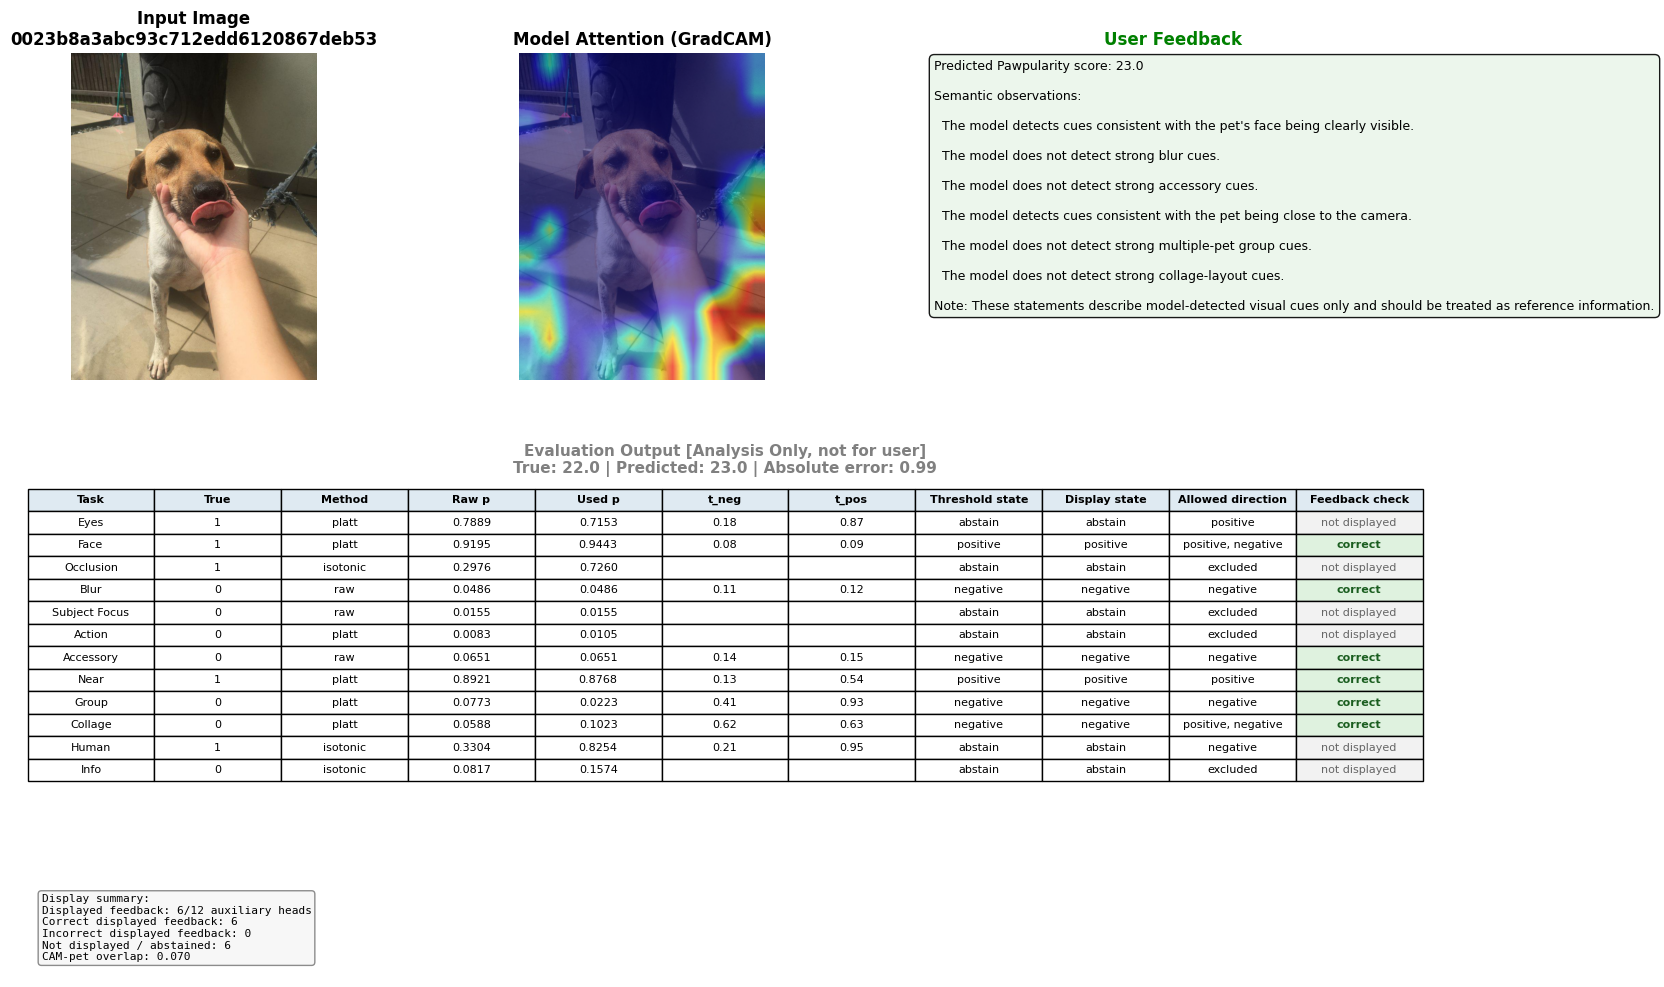

In [25]:
# %% part 25 — single-image batch, using the already loaded  model.

from pathlib import Path

image_fold_by_id = aux_df.set_index("Id")["fold"].to_dict()
assert image_fold_by_id[example_id] == MODEL_FOLD == 4

CHECK_SWIN_GRID = (7, 7)
CHECK_IMAGE_FOLDER = IMG_FOLDER

assert Path(CHECK_IMAGE_FOLDER, example_id + ".jpg").is_file()

true_paw_dict = df.set_index("Id")["Pawpularity"].to_dict()

true_aux_dict = {
    row["Id"]: {
        task: int(row[task])
        for task in CALIBRATION_TASKS
    }
    for _, row in df.iterrows()
}

batch_check = run_batch(
    image_ids=[example_id],
    img_folder=CHECK_IMAGE_FOLDER,
    cfg=ACTIVE_CFG,
    models_by_fold={MODEL_FOLD: prototype_models[0]},
    aux_tasks=CALIBRATION_TASKS,
    swin_grid=CHECK_SWIN_GRID,
    device=device,
    image_fold_by_id=image_fold_by_id,
    predict_aux_selective=predict_aux_selective,
    true_paw_dict=true_paw_dict,
    true_aux_dict=true_aux_dict,
    use_yolo=True,
)

Predicted 250/3964 held-out images
Predicted 500/3964 held-out images
Predicted 750/3964 held-out images
Predicted 1000/3964 held-out images
Predicted 1250/3964 held-out images
Predicted 1500/3964 held-out images
Predicted 1750/3964 held-out images
Predicted 2000/3964 held-out images
Predicted 2250/3964 held-out images
Predicted 2500/3964 held-out images
Predicted 2750/3964 held-out images
Predicted 3000/3964 held-out images
Predicted 3250/3964 held-out images
Predicted 3500/3964 held-out images
Predicted 3750/3964 held-out images
Predicted 3964/3964 held-out images
Selected held-out cases:


,case_group,case_type,Id,fold,score_range,true_paw,pred_paw,signed_error,absolute_error
0,Error analysis,Lowest absolute error,449e69e68743c62dc26b791dd8aa4c7e,4,Low,23.0,23.001,0.001,0.001
1,Error analysis,Lowest absolute error,4204c677b9af7c01d5529ba2c19e7b51,5,Middle,63.0,62.993,-0.007,0.007
2,Error analysis,Highest absolute error,4435d6f98ad72782ca0cf61f946b016d,5,High,100.0,27.078,-72.922,72.922
3,Error analysis,Highest absolute error,941e532a21f7edb21766e88a15e588cb,4,High,100.0,30.122,-69.878,69.878
4,True Pawpularity range,Low true Pawpularity,0023b8a3abc93c712edd6120867deb53,4,Low,22.0,22.995,0.995,0.995
5,True Pawpularity range,Low true Pawpularity,077abdabd20b80ff9afee6cee33ccbba,4,Low,22.0,28.263,6.263,6.263
6,True Pawpularity range,Middle true Pawpularity,023e9c4a27815c9987e591e5e52ab291,4,Middle,50.0,59.390,9.390,9.390
7,True Pawpularity range,Middle true Pawpularity,03f9353072191f8877825f0c7eefbea7,5,Middle,50.0,38.291,-11.709,11.709
8,True Pawpularity range,High true Pawpularity,463e2b8a0e55605efa93093a4b5f036f,5,High,85.0,46.759,-38.241,38.241
9,True Pawpularity range,High true Pawpularity,5c4ae380390c120e93cafe3a50d1d540,5,High,85.0,59.647,-25.353,25.353


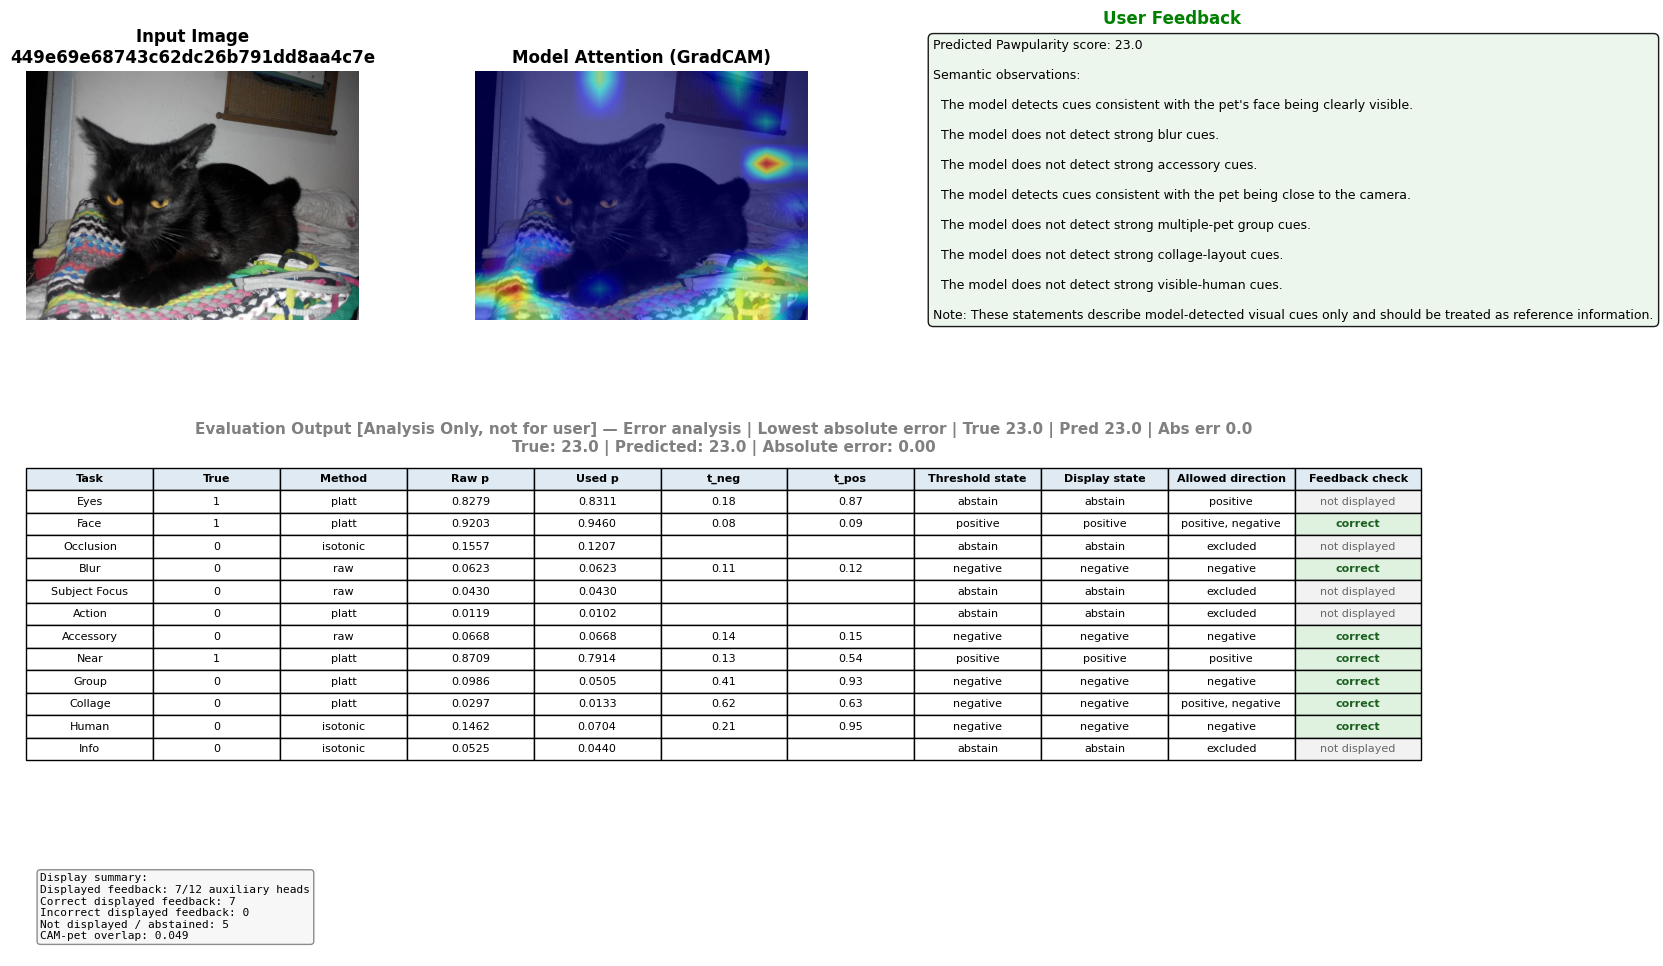

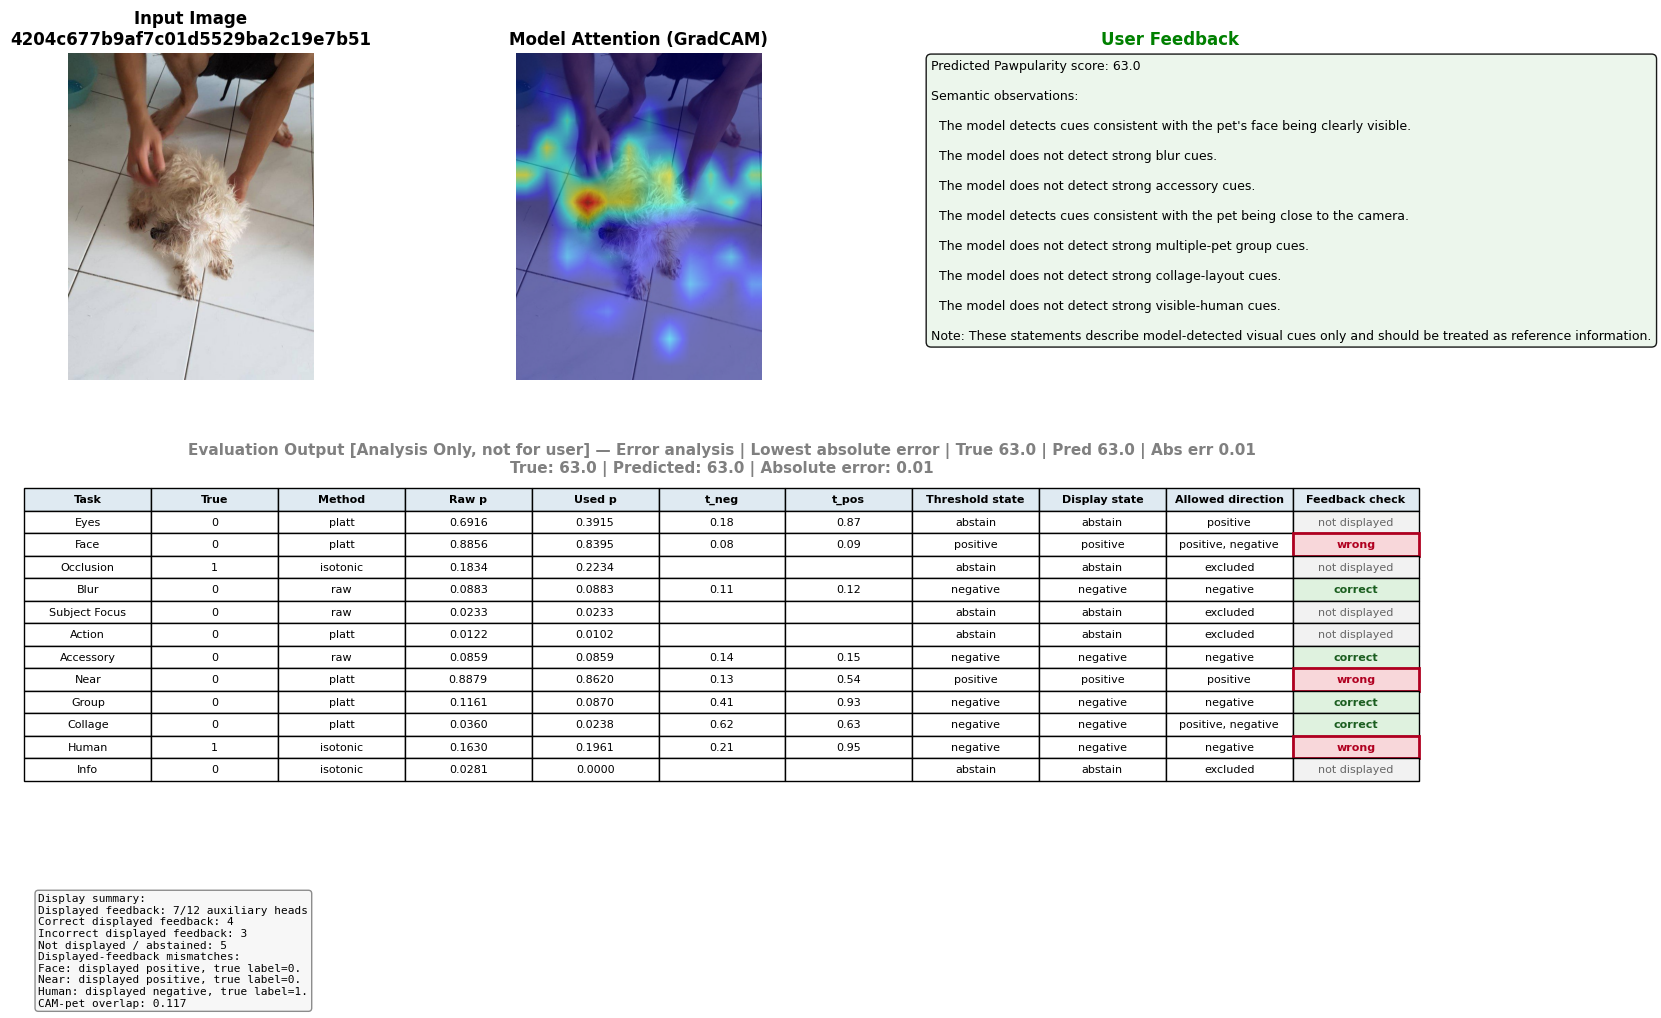

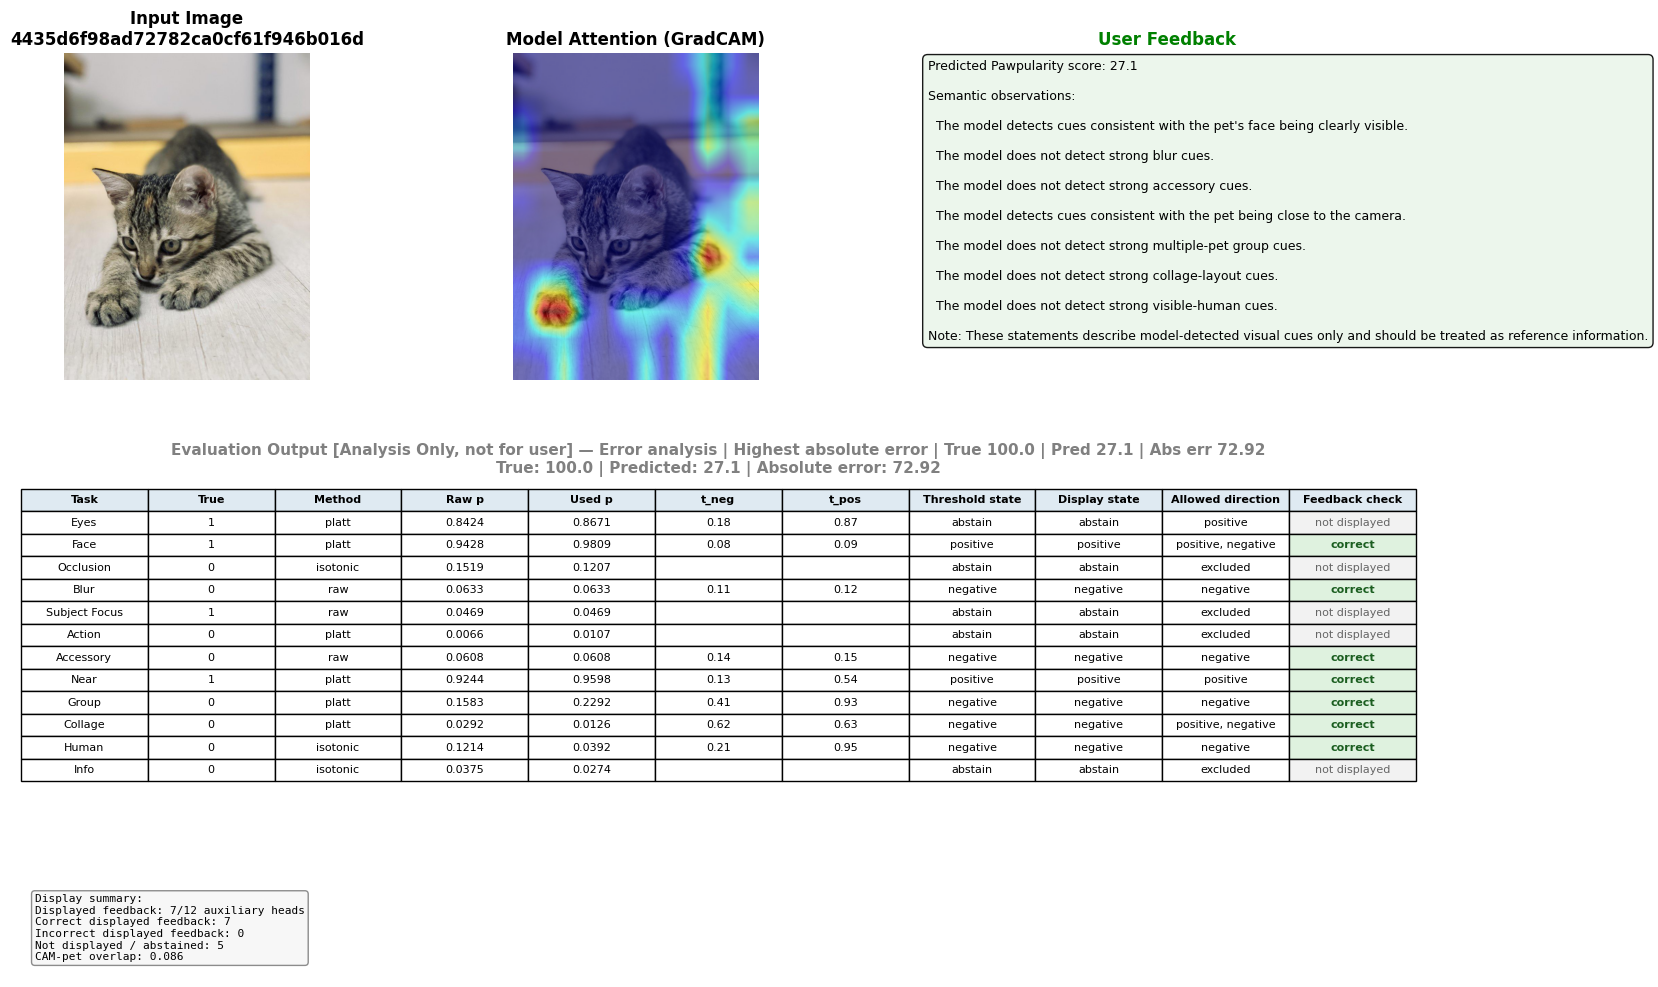

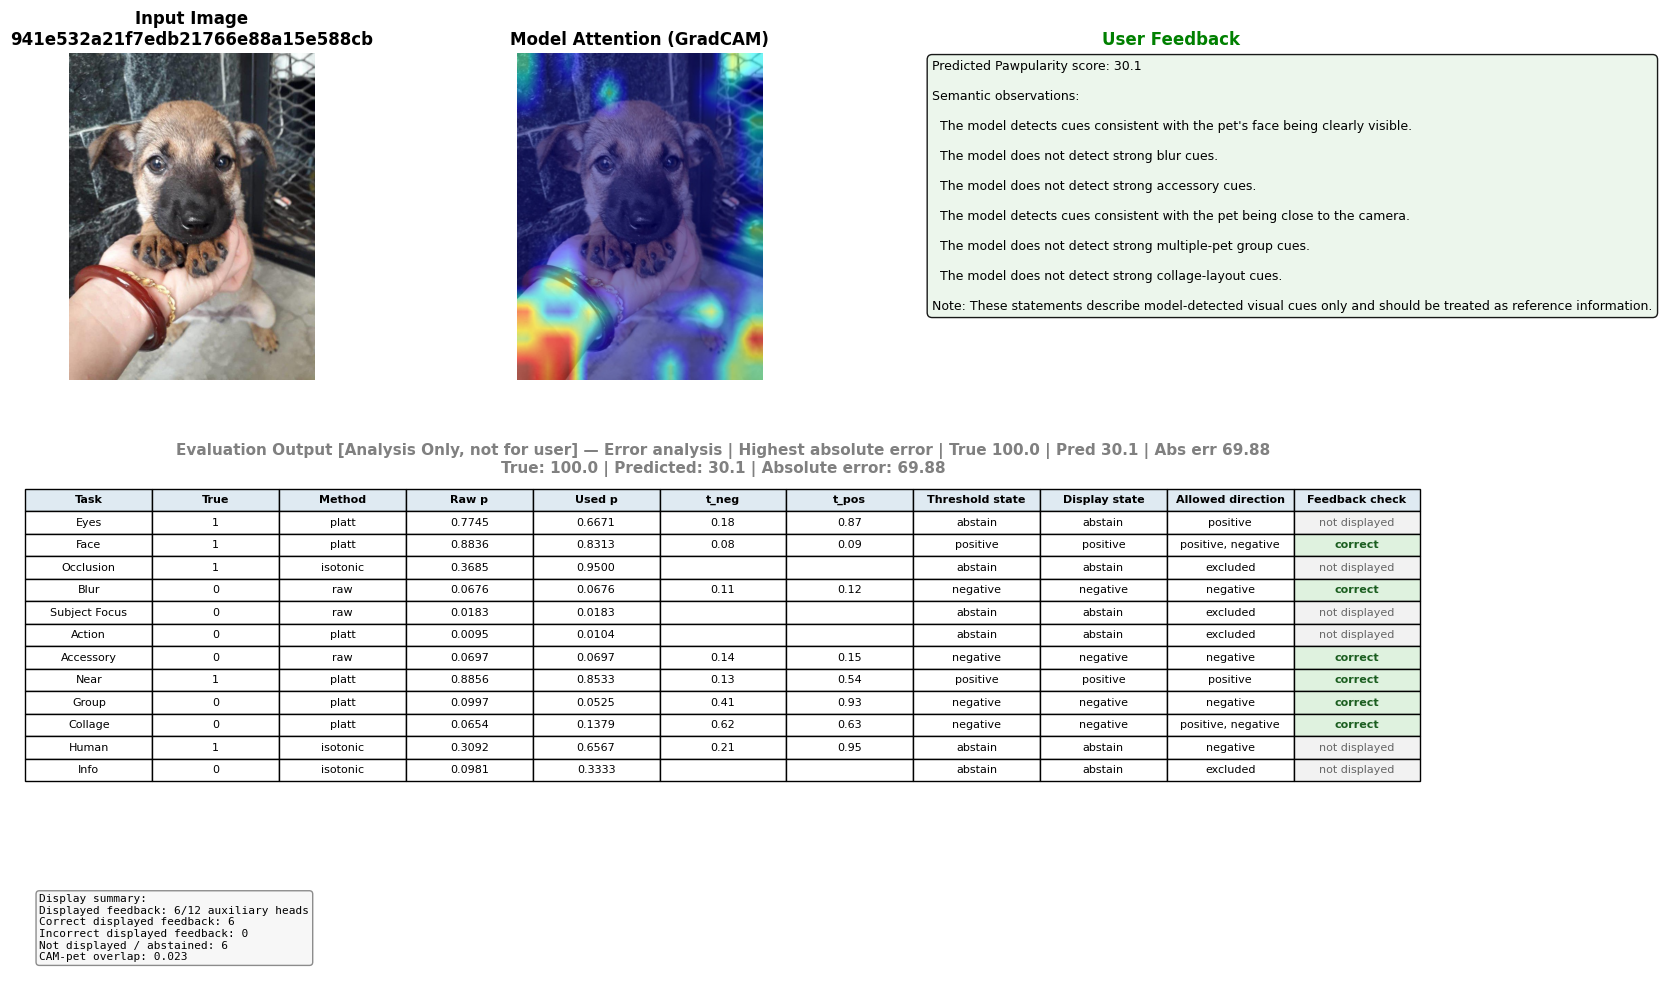

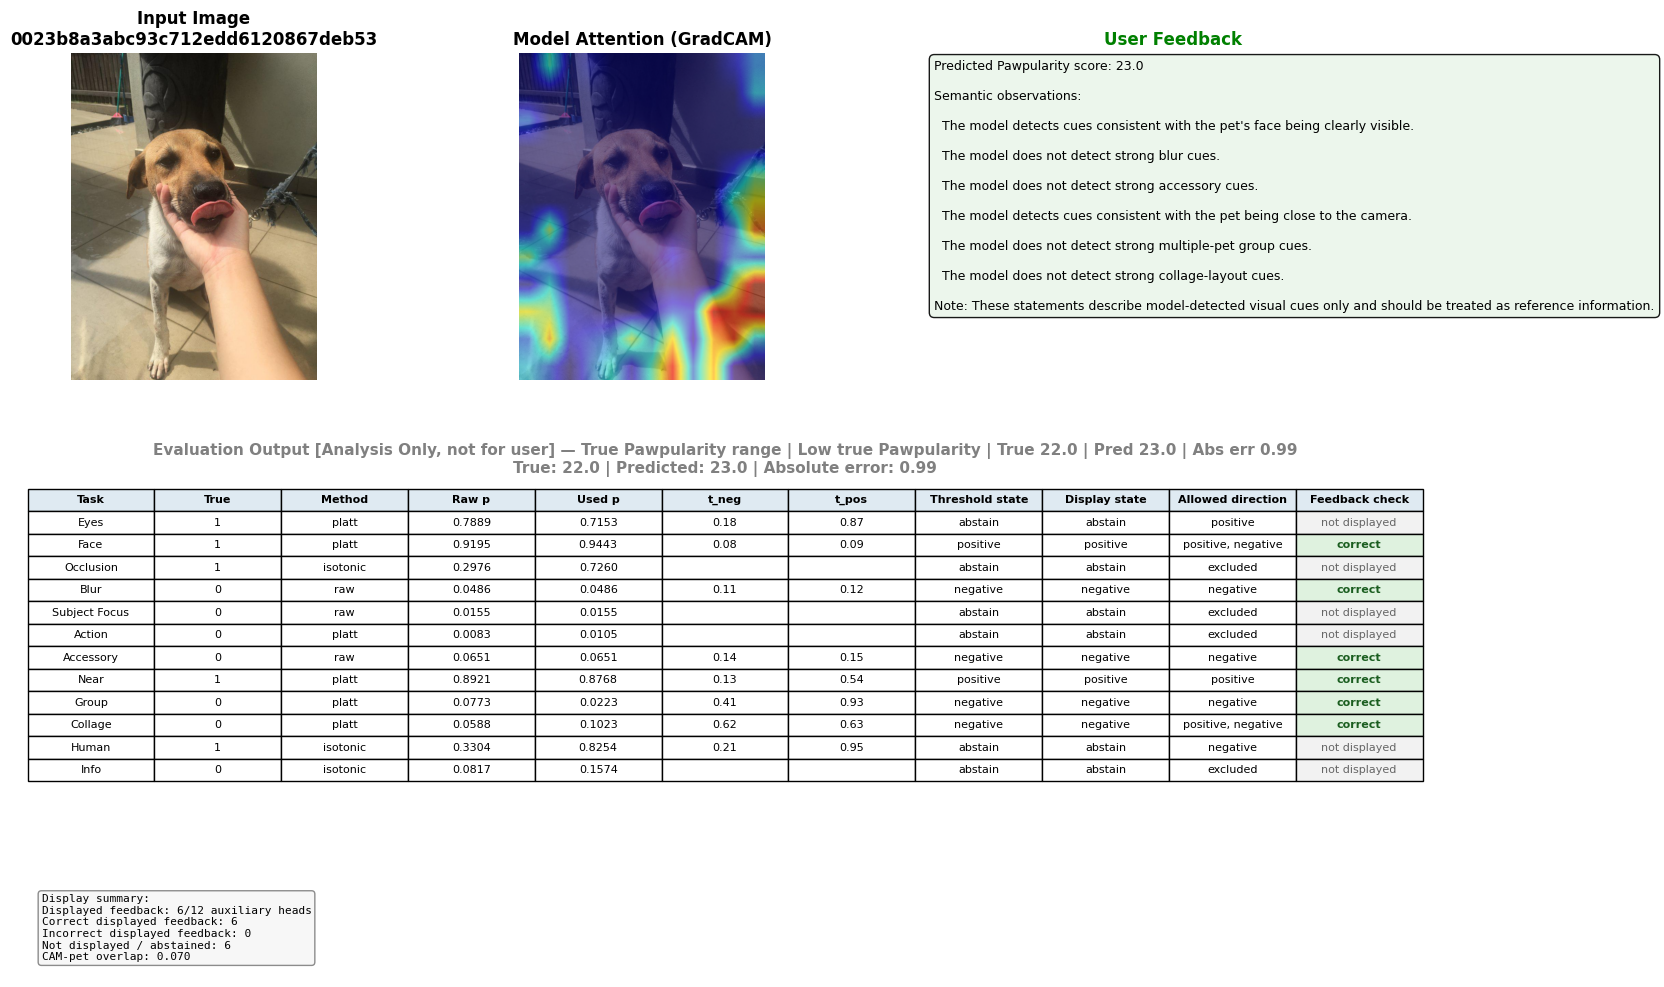

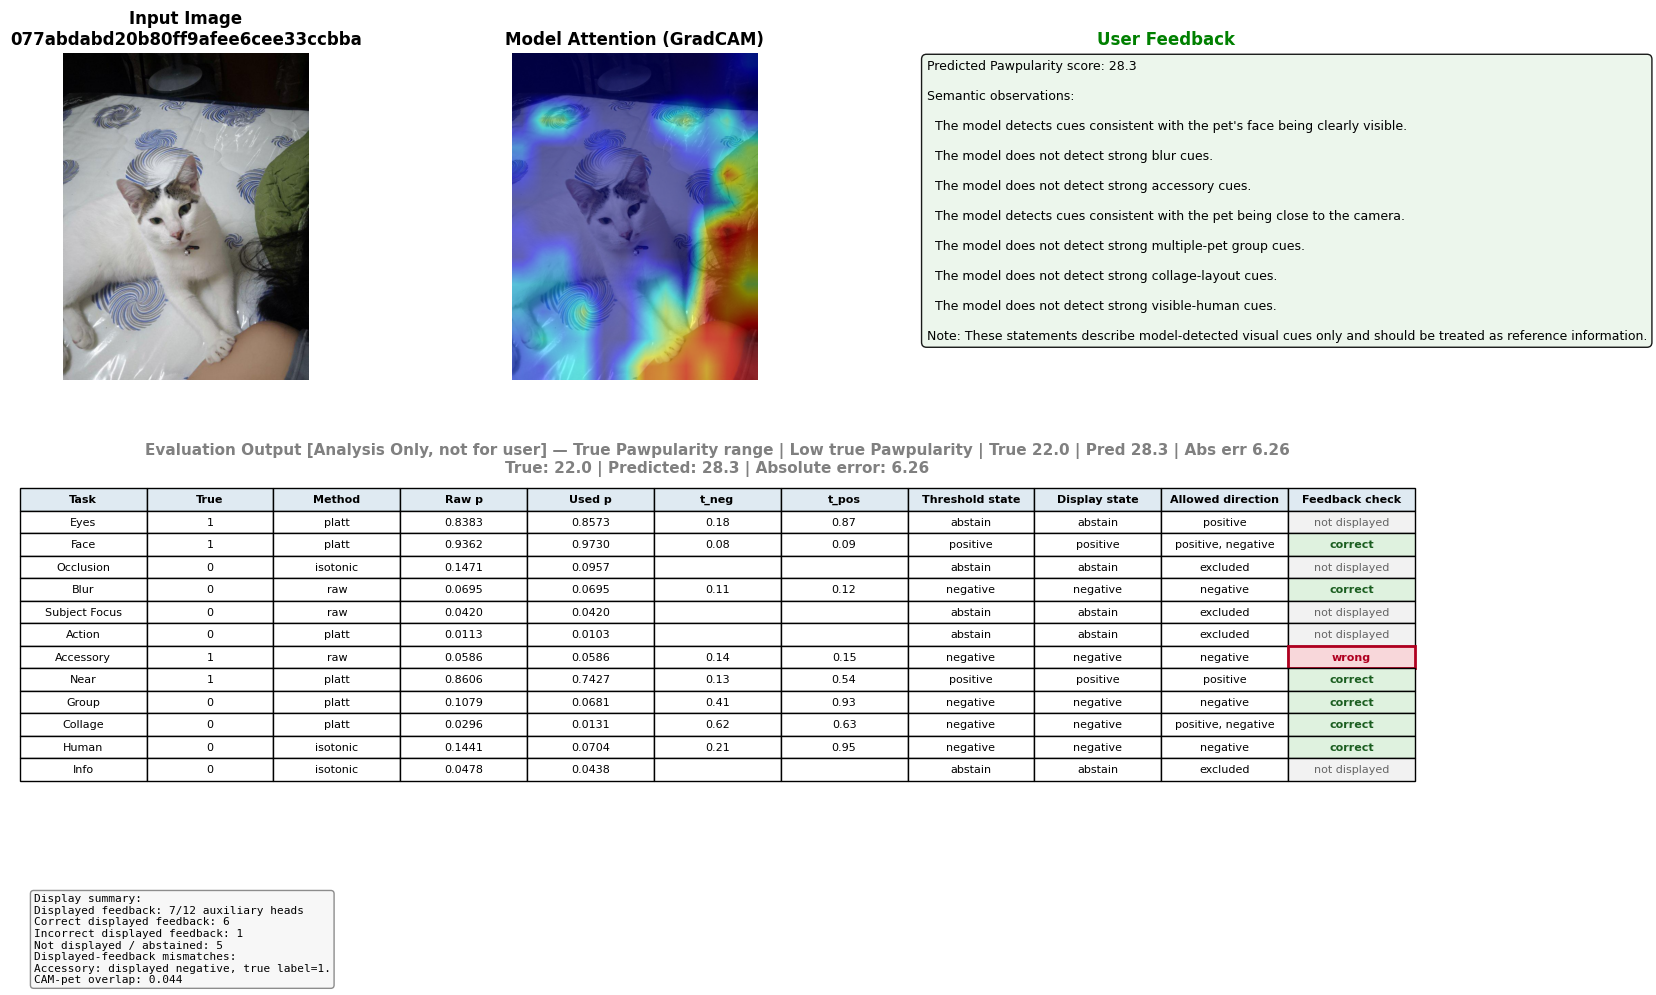

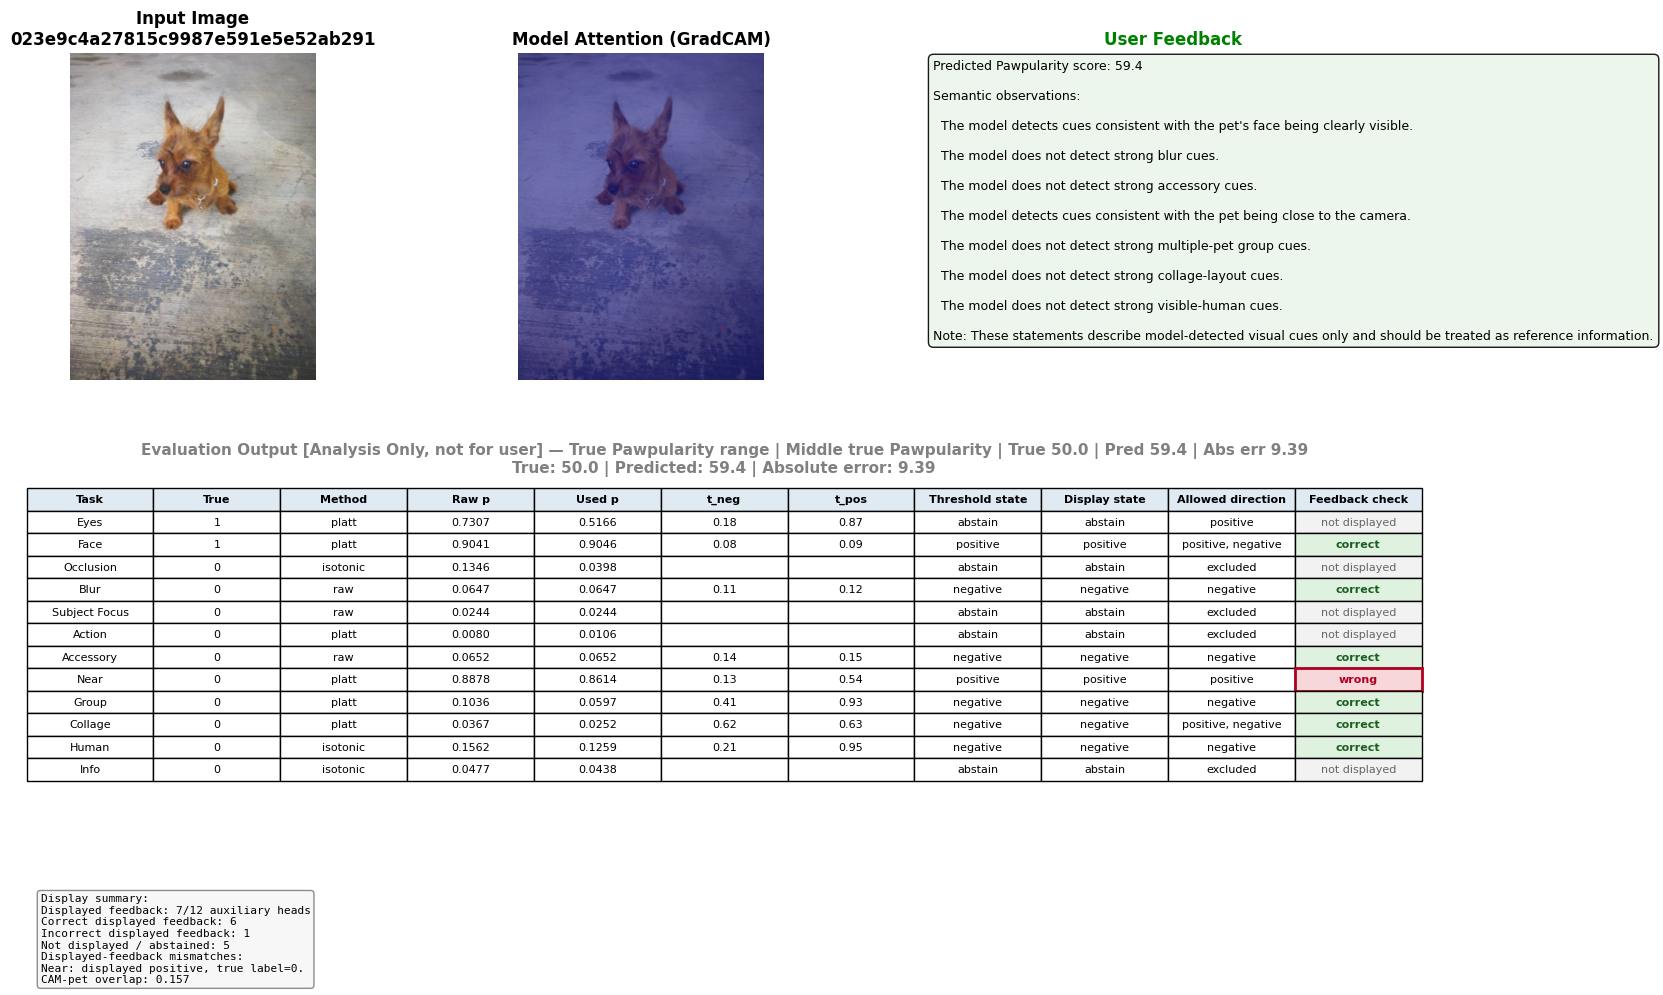

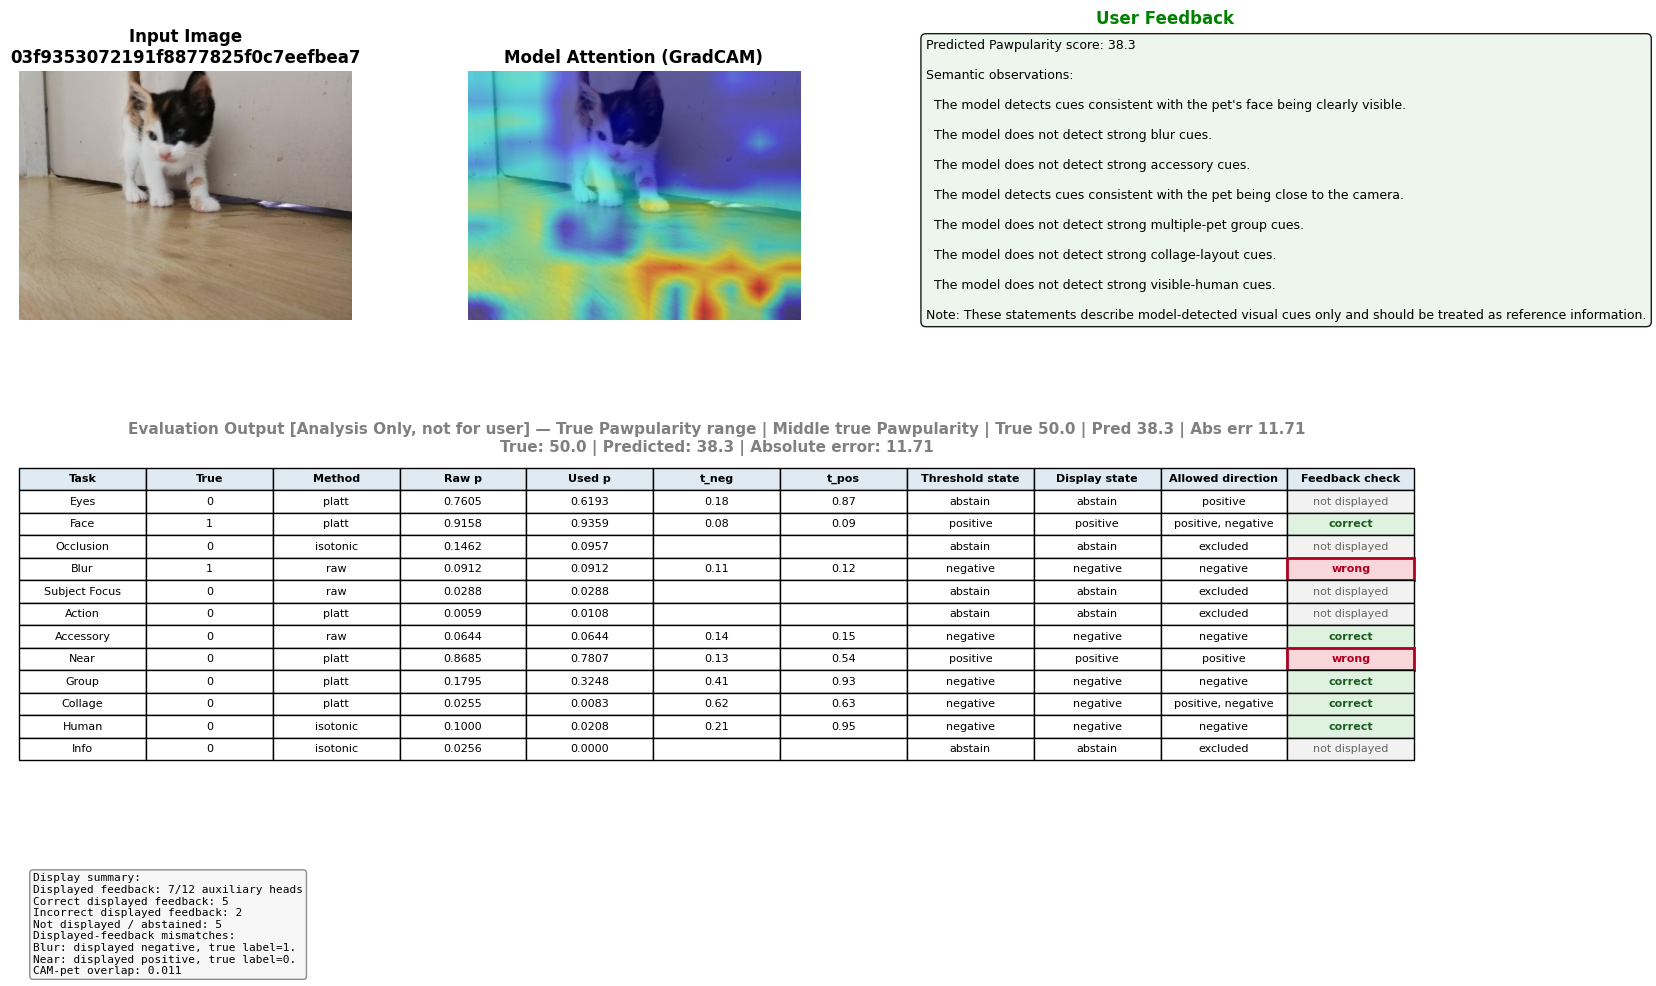

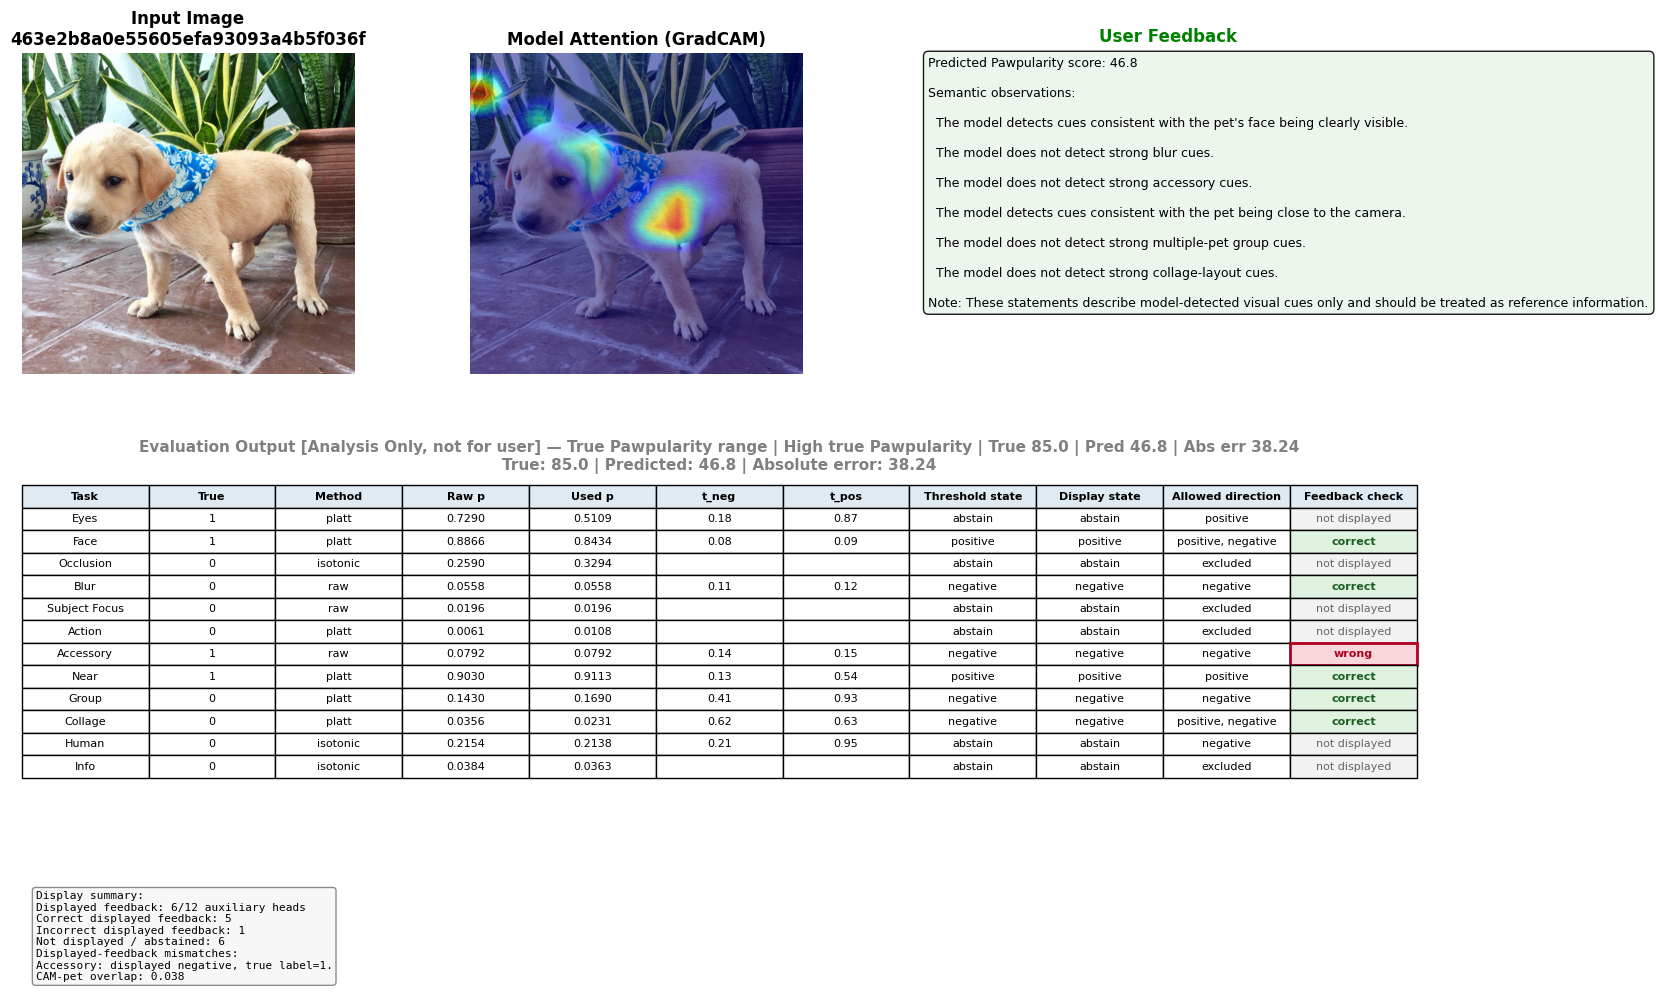

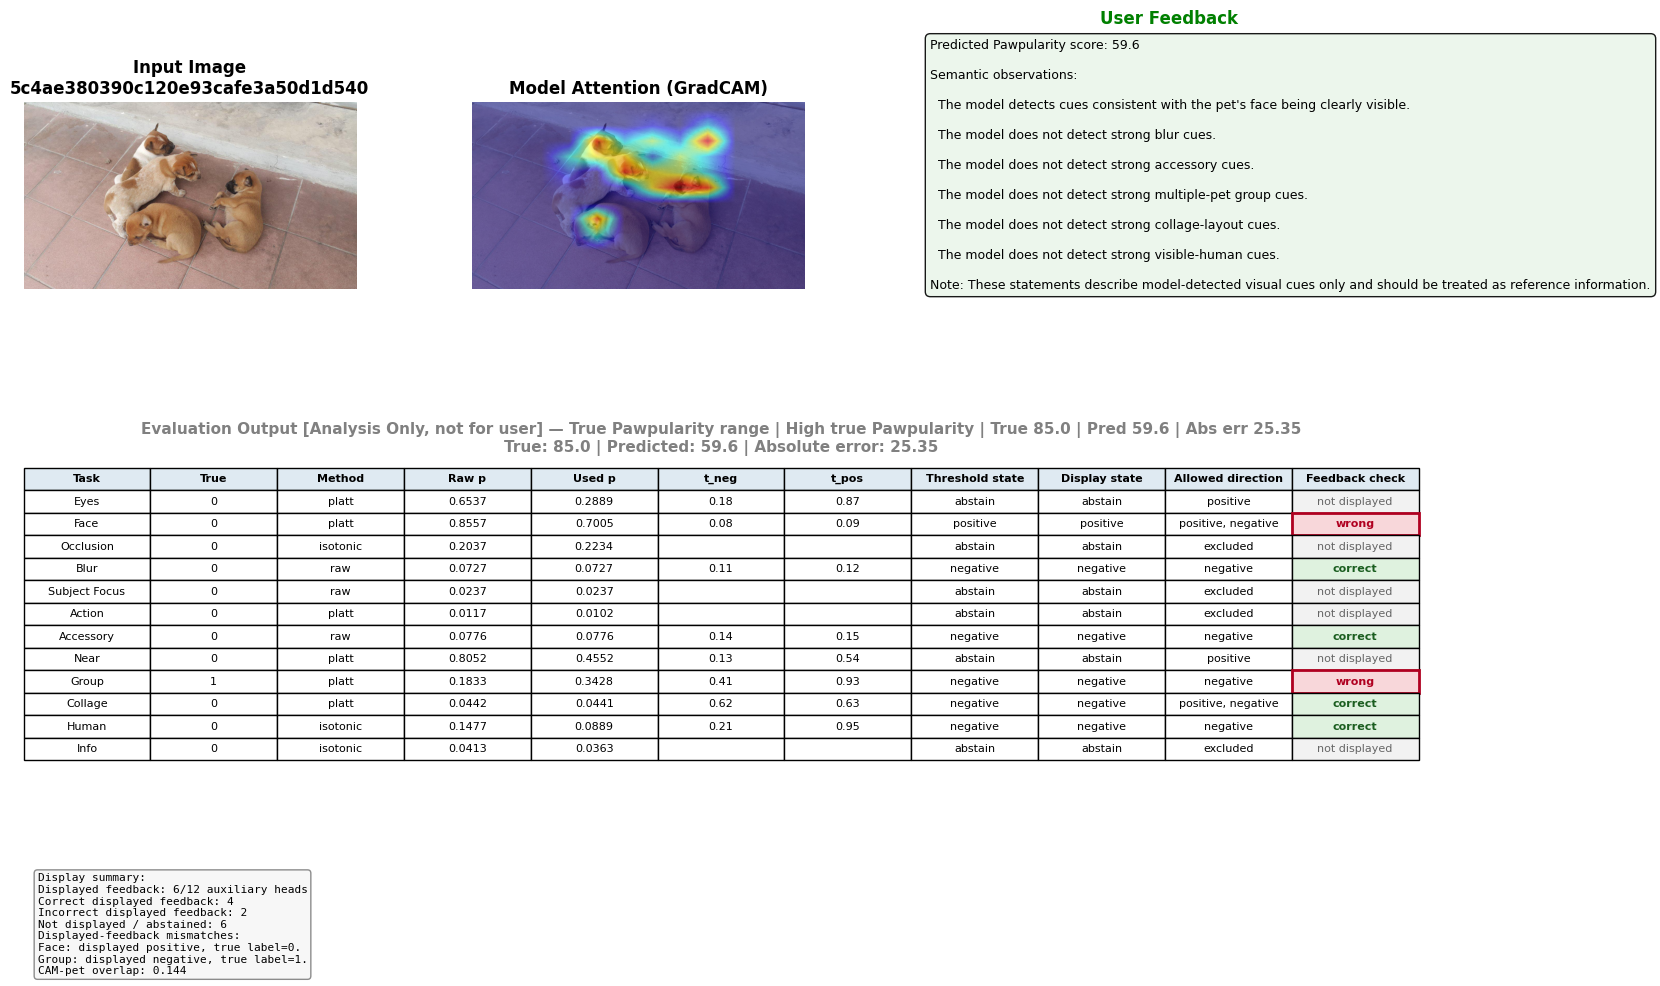

,Id,fold,true_paw,pred_paw,cam_pet_overlap,eyes_true,eyes_raw_probability,eyes_calibrated_probability,eyes_threshold_state,eyes_prototype_state,...,human_prototype_state,human_prob,human_pred,info_true,info_raw_probability,info_calibrated_probability,info_threshold_state,info_prototype_state,info_prob,info_pred
0,449e69e68743c62dc26b791dd8aa4c7e,4,23,23.000641,0.049021,1,0.827883,0.831131,abstain,abstain,...,negative,0.070352,0.0,0,0.052492,0.043974,abstain,abstain,0.043974,None
1,4204c677b9af7c01d5529ba2c19e7b51,5,63,62.992924,0.116938,0,0.691631,0.391483,abstain,abstain,...,negative,0.196078,0.0,0,0.028100,0.000000,abstain,abstain,0.000000,None
2,4435d6f98ad72782ca0cf61f946b016d,5,100,27.077641,0.086371,1,0.842420,0.867084,abstain,abstain,...,negative,0.039179,0.0,0,0.037473,0.027397,abstain,abstain,0.027397,None
3,941e532a21f7edb21766e88a15e588cb,4,100,30.122242,0.023294,1,0.774489,0.667136,abstain,abstain,...,abstain,0.656716,NaN,0,0.098108,0.333333,abstain,abstain,0.333333,None
4,0023b8a3abc93c712edd6120867deb53,4,22,22.994572,0.070010,1,0.788930,0.715252,abstain,abstain,...,abstain,0.825397,NaN,0,0.081737,0.157407,abstain,abstain,0.157407,None
5,077abdabd20b80ff9afee6cee33ccbba,4,22,28.262936,0.044073,1,0.838256,0.857253,abstain,abstain,...,negative,0.070352,0.0,0,0.047840,0.043779,abstain,abstain,0.043779,None
6,023e9c4a27815c9987e591e5e52ab291,4,50,59.389870,0.157221,1,0.730670,0.516583,abstain,abstain,...,negative,0.125874,0.0,0,0.047738,0.043779,abstain,abstain,0.043779,None
7,03f9353072191f8877825f0c7eefbea7,5,50,38.291115,0.011054,0,0.760540,0.619333,abstain,abstain,...,negative,0.020833,0.0,0,0.025561,0.000000,abstain,abstain,0.000000,None
8,463e2b8a0e55605efa93093a4b5f036f,5,85,46.759365,0.037675,1,0.728992,0.510915,abstain,abstain,...,abstain,0.213766,NaN,0,0.038421,0.036279,abstain,abstain,0.036279,None
9,5c4ae380390c120e93cafe3a50d1d540,5,85,59.646835,0.144449,0,0.653712,0.288896,abstain,abstain,...,negative,0.088889,0.0,0,0.041298,0.036279,abstain,abstain,0.036279,None


In [26]:
# ===================== part 26 ====================================
# Select and visualize held-out examples:
#
# A. Error-based:
#    - 2 lowest absolute-error images
#    - 2 highest absolute-error images
#
# B. True Pawpularity range:
#    - 2 Low true-score images
#    - 2 Middle true-score images
#    - 2 High true-score images
#
# All examples come only from folds 4 and 5.
# ================================================================

from src.inference_feedback import (
    preprocess,
    predict_pawpularity,
)

# ------------------------------------------------------------
# 1. Build held-out image list
# ------------------------------------------------------------

image_fold_by_id = aux_df.set_index("Id")["fold"].to_dict()
true_paw_dict = df.set_index("Id")["Pawpularity"].to_dict()

true_aux_dict = {
    row["Id"]: {
        task: int(row[task])
        for task in CALIBRATION_TASKS
    }
    for _, row in df.iterrows()
}

heldout_ids = (
    aux_df[
        aux_df["fold"].isin(THRESHOLD_EVALUATION_FOLDS)
    ]["Id"]
    .tolist()
)


# ------------------------------------------------------------
# 2. Load fold models needed for folds 4 and 5
# ------------------------------------------------------------

models_by_fold = {}

for fold in THRESHOLD_EVALUATION_FOLDS:

    if "prototype_models" in globals() and fold == MODEL_FOLD:
        models_by_fold[fold] = prototype_models[0]

    else:
        models_by_fold[fold] = load_model(
            fold=int(fold),
            cfg=ACTIVE_CFG,
            out_dir=ACTIVE_DIR,
            device=device,
        )


# ------------------------------------------------------------
# 3. Predict Pawpularity for all held-out images
# ------------------------------------------------------------

heldout_rows = []

for i, img_id in enumerate(heldout_ids, start=1):

    fold = int(image_fold_by_id[img_id])

    img_path = os.path.join(
        IMG_FOLDER,
        img_id + ".jpg",
    )

    img_tensor, _ = preprocess(
        img_path,
        ACTIVE_CFG,
    )

    pred_paw = predict_pawpularity(
        img_tensor=img_tensor,
        allFolds_models=[models_by_fold[fold]],
        device=device,
        fold=0,
    )

    true_paw = float(true_paw_dict[img_id])

    heldout_rows.append({
        "Id": img_id,
        "fold": fold,
        "true_paw": true_paw,
        "pred_paw": float(pred_paw),
        "signed_error": float(pred_paw - true_paw),
        "absolute_error": abs(float(pred_paw - true_paw)),
    })

    if i % 250 == 0 or i == len(heldout_ids):
        print(f"Predicted {i}/{len(heldout_ids)} held-out images")


heldout_paw_results = pd.DataFrame(heldout_rows)

heldout_paw_results["score_range"] = pd.cut(
    heldout_paw_results["true_paw"],
    bins=[-np.inf, 34, 67, np.inf],
    labels=["Low", "Middle", "High"],
)


# ------------------------------------------------------------
# 4. Select requested cases
# ------------------------------------------------------------

case_parts = []


# A. 2 lowest absolute-error images
lowest_error_cases = (
    heldout_paw_results
    .sort_values(["absolute_error", "Id"])
    .head(2)
    .copy()
)

lowest_error_cases["case_group"] = "Error analysis"
lowest_error_cases["case_type"] = "Lowest absolute error"

case_parts.append(lowest_error_cases)


# B. 2 highest absolute-error images
highest_error_cases = (
    heldout_paw_results
    .sort_values(["absolute_error", "Id"], ascending=[False, True])
    .head(2)
    .copy()
)

highest_error_cases["case_group"] = "Error analysis"
highest_error_cases["case_type"] = "Highest absolute error"

case_parts.append(highest_error_cases)


# C. 2 images from each true Pawpularity range
#  examples closest to the middle of each range, so they are typical
# of that range rather than extreme boundary cases.

range_targets = {
    "Low": 22.0,
    "Middle": 50.0,
    "High": 85.0,
}

for score_range, target_score in range_targets.items():

    range_cases = (
        heldout_paw_results[
            heldout_paw_results["score_range"].astype(str) == score_range
        ]
        .copy()
    )

    range_cases["distance_to_range_target"] = (
        range_cases["true_paw"] - target_score
    ).abs()

    selected_range_cases = (
        range_cases
        .sort_values(
            [
                "distance_to_range_target",
                "Id",
            ]
        )
        .head(2)
        .copy()
    )

    selected_range_cases["case_group"] = "True Pawpularity range"
    selected_range_cases["case_type"] = f"{score_range} true Pawpularity"

    case_parts.append(selected_range_cases)


selected_cases_df = (
    pd.concat(case_parts, ignore_index=True)
    .drop_duplicates(subset=["Id"], keep="first")
    .reset_index(drop=True)
)

selected_cases_df["case_label"] = (
    selected_cases_df["case_group"]
    + " | "
    + selected_cases_df["case_type"]
    + " | True "
    + selected_cases_df["true_paw"].round(1).astype(str)
    + " | Pred "
    + selected_cases_df["pred_paw"].round(1).astype(str)
    + " | Abs err "
    + selected_cases_df["absolute_error"].round(2).astype(str)
)


print("Selected held-out cases:")
display(
    selected_cases_df[
        [
            "case_group",
            "case_type",
            "Id",
            "fold",
            "score_range",
            "true_paw",
            "pred_paw",
            "signed_error",
            "absolute_error",
        ]
    ].round(3)
)


# ------------------------------------------------------------
# 5.  GradCAM + feedback visualization
# ------------------------------------------------------------

case_labels = dict(
    zip(
        selected_cases_df["Id"],
        selected_cases_df["case_label"],
    )
)

case_batch_results = run_batch(
    image_ids=selected_cases_df["Id"].tolist(),
    img_folder=IMG_FOLDER,
    cfg=ACTIVE_CFG,
    models_by_fold=models_by_fold,
    aux_tasks=CALIBRATION_TASKS,
    swin_grid=CHECK_SWIN_GRID,
    device=device,
    image_fold_by_id=image_fold_by_id,
    predict_aux_selective=predict_aux_selective,
    true_paw_dict=true_paw_dict,
    true_aux_dict=true_aux_dict,
    use_yolo=True,
    labels=case_labels,
)

display(case_batch_results)